In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
from scipy.signal import savgol_filter

#define system parameters
maxout = 1000
temp = 900.0
tau0 = 150.0
lgb = 0.1
grain_size = 1.0
tfin = 1.5e9
niter = 500_000_000
#ngbn = 41 #int(lgb/delta)
#if ngbn % 2 == 0: ngbn += 1

#define parameter to be varied
nlist = [11, 21, 31, 41]
Np = len(nlist)
#flist = ["pu1_Ngbn11_tau150_T900", "pu1_Ngbn21_tau150_T900", "pu1_Ngbn31_tau150_T900", "pu1_Ngbn41_tau150_T900"]
#Np = len(flist)

# initialize arrays to store individual simulation results
psr_av = np.zeros((Np, maxout))
gplast = np.zeros((Np, maxout))
sim_time = np.zeros((Np, maxout))
nit = np.zeros(Np, dtype=int)
Ngb_list = np.zeros(Np, dtype=int)

In [ ]:
# if result files exits, read them
for i, fname in enumerate(flist):
    gbdd = dd.GB_dislocations(from_file="../examples/gbdd/"+fname+".h5")
    print(f"Data file with N_gbn={gbdd.Ngbn}, delta={gbdd.Dgp}, dtmax={gbdd.dtmax}")
    gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
    gbdd.plot_time_series('plast_slip_rate')
    gbdd.plot_time_series('psr_av')
    gbdd.plot_field('displacement')
    gbdd.plot_field('bfield')
    nit[i] = gbdd.nout
    Ngb_list[i] = gbdd.Ngbn
    sim_time[i, 0:gbdd.nout] = gbdd.sim_time
    psr_av[i, 0:gbdd.nout-1] = savgol_filter(gbdd.glob_data['psr_av'][:-1], window_length=25, polyorder=1, deriv=0)
    gplast[i, 0:gbdd.nout] = gbdd.glob_data['plastic_slip']
                          

Simulation with N_gbn=11, delta=0.01, dtmax=62.50000000000001
 Starting iteration for T, tau0, D2, Lgb, Ngbn   900.00000000000000        150.00000000000000        1.0000000000000000       0.10000000000000001               11
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)     5000000  0.19277894775323451        45.733612455231409        3.2420815360959822E-010   2.7628199860259457E-004          10           1  0.96441652505217368     
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)    10000000   2.4824138363793096        53.613993895988614        2.5176643015980233E-011   7.8853591955260478E-004          10           3  0.99890827017680495     
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)    15000000  0.45241199993574271        67.919314036176502        1.3814965559720297E-010   9.9329798899194365E-004          11           4  0.99265744416801582     
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)    200000

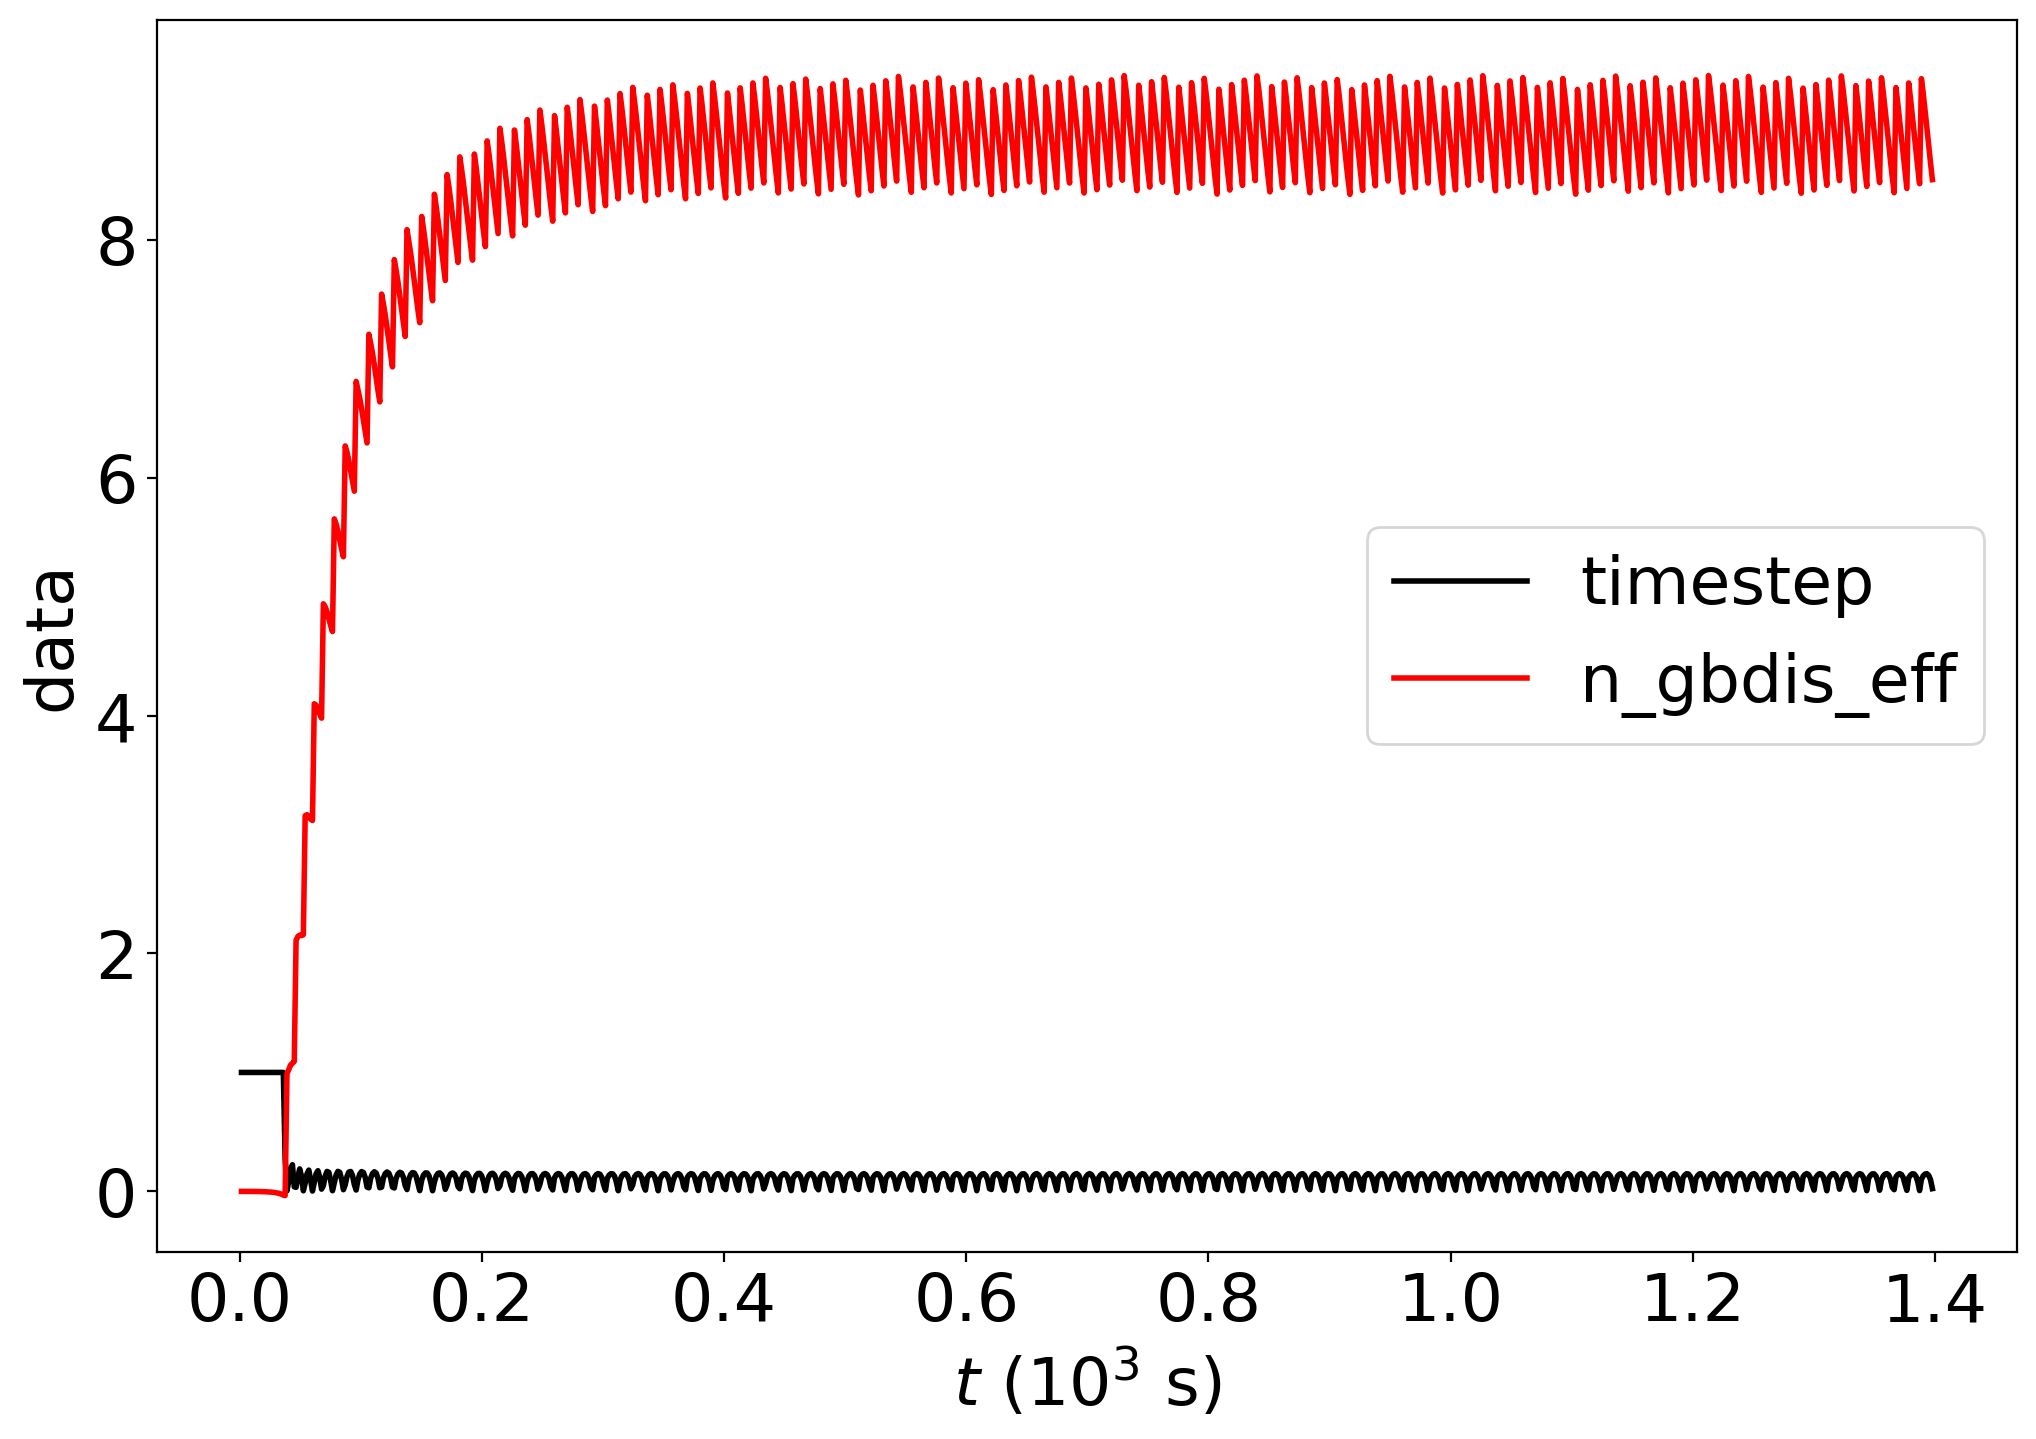

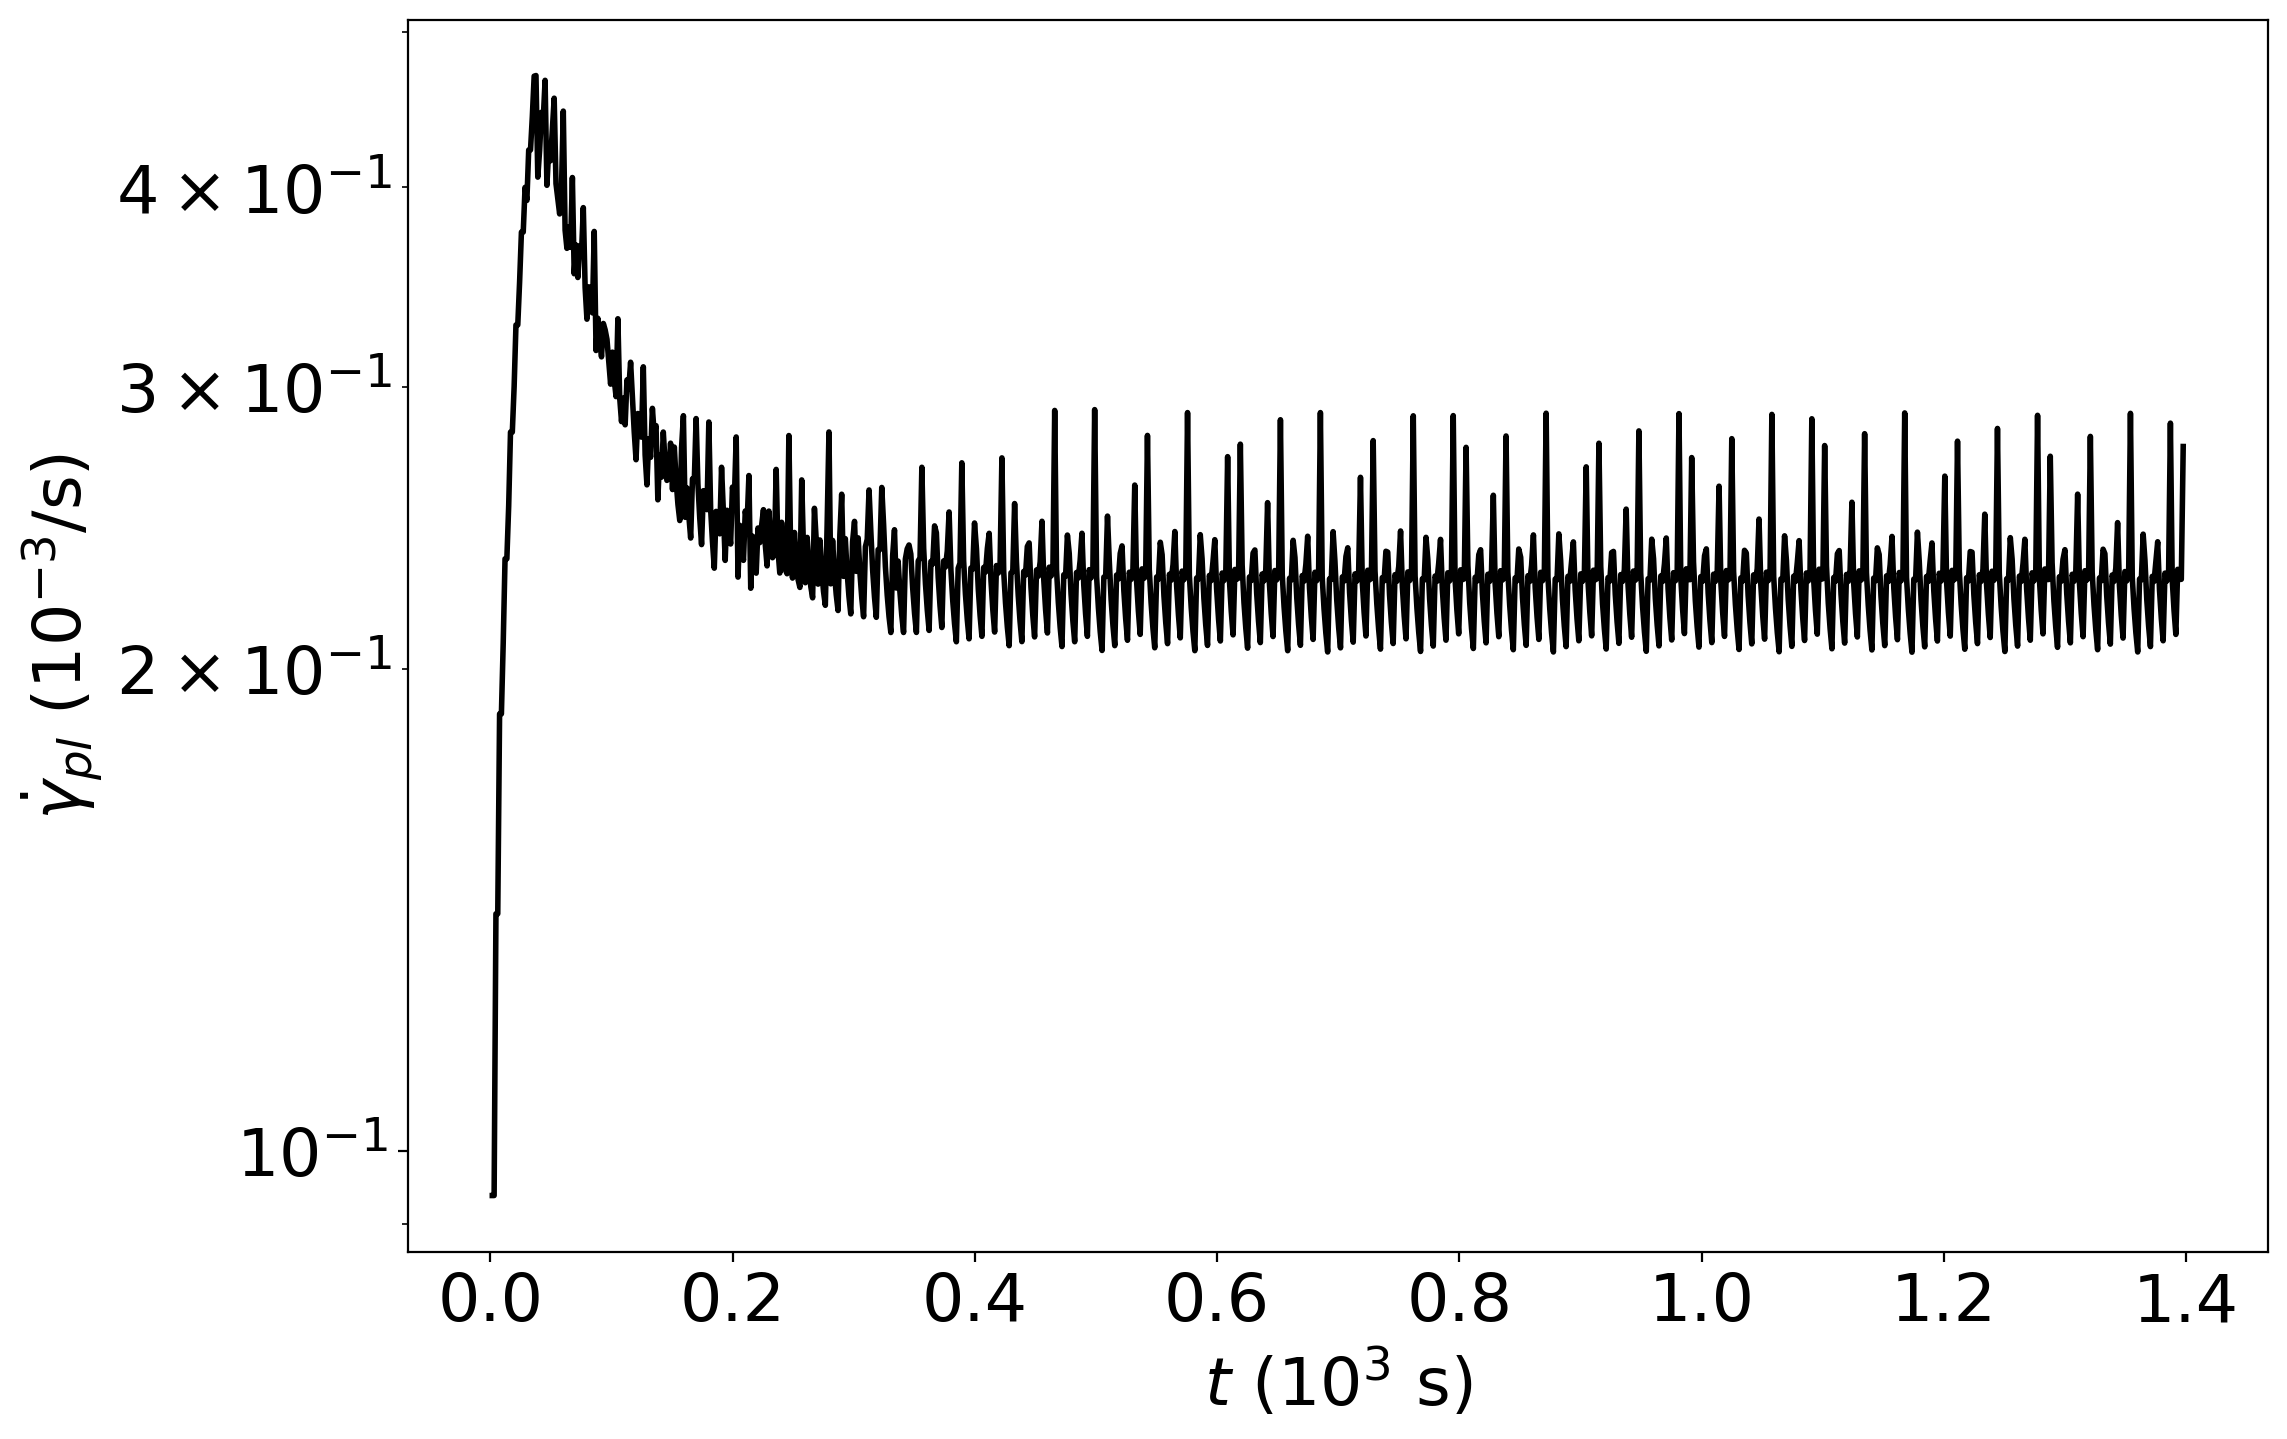

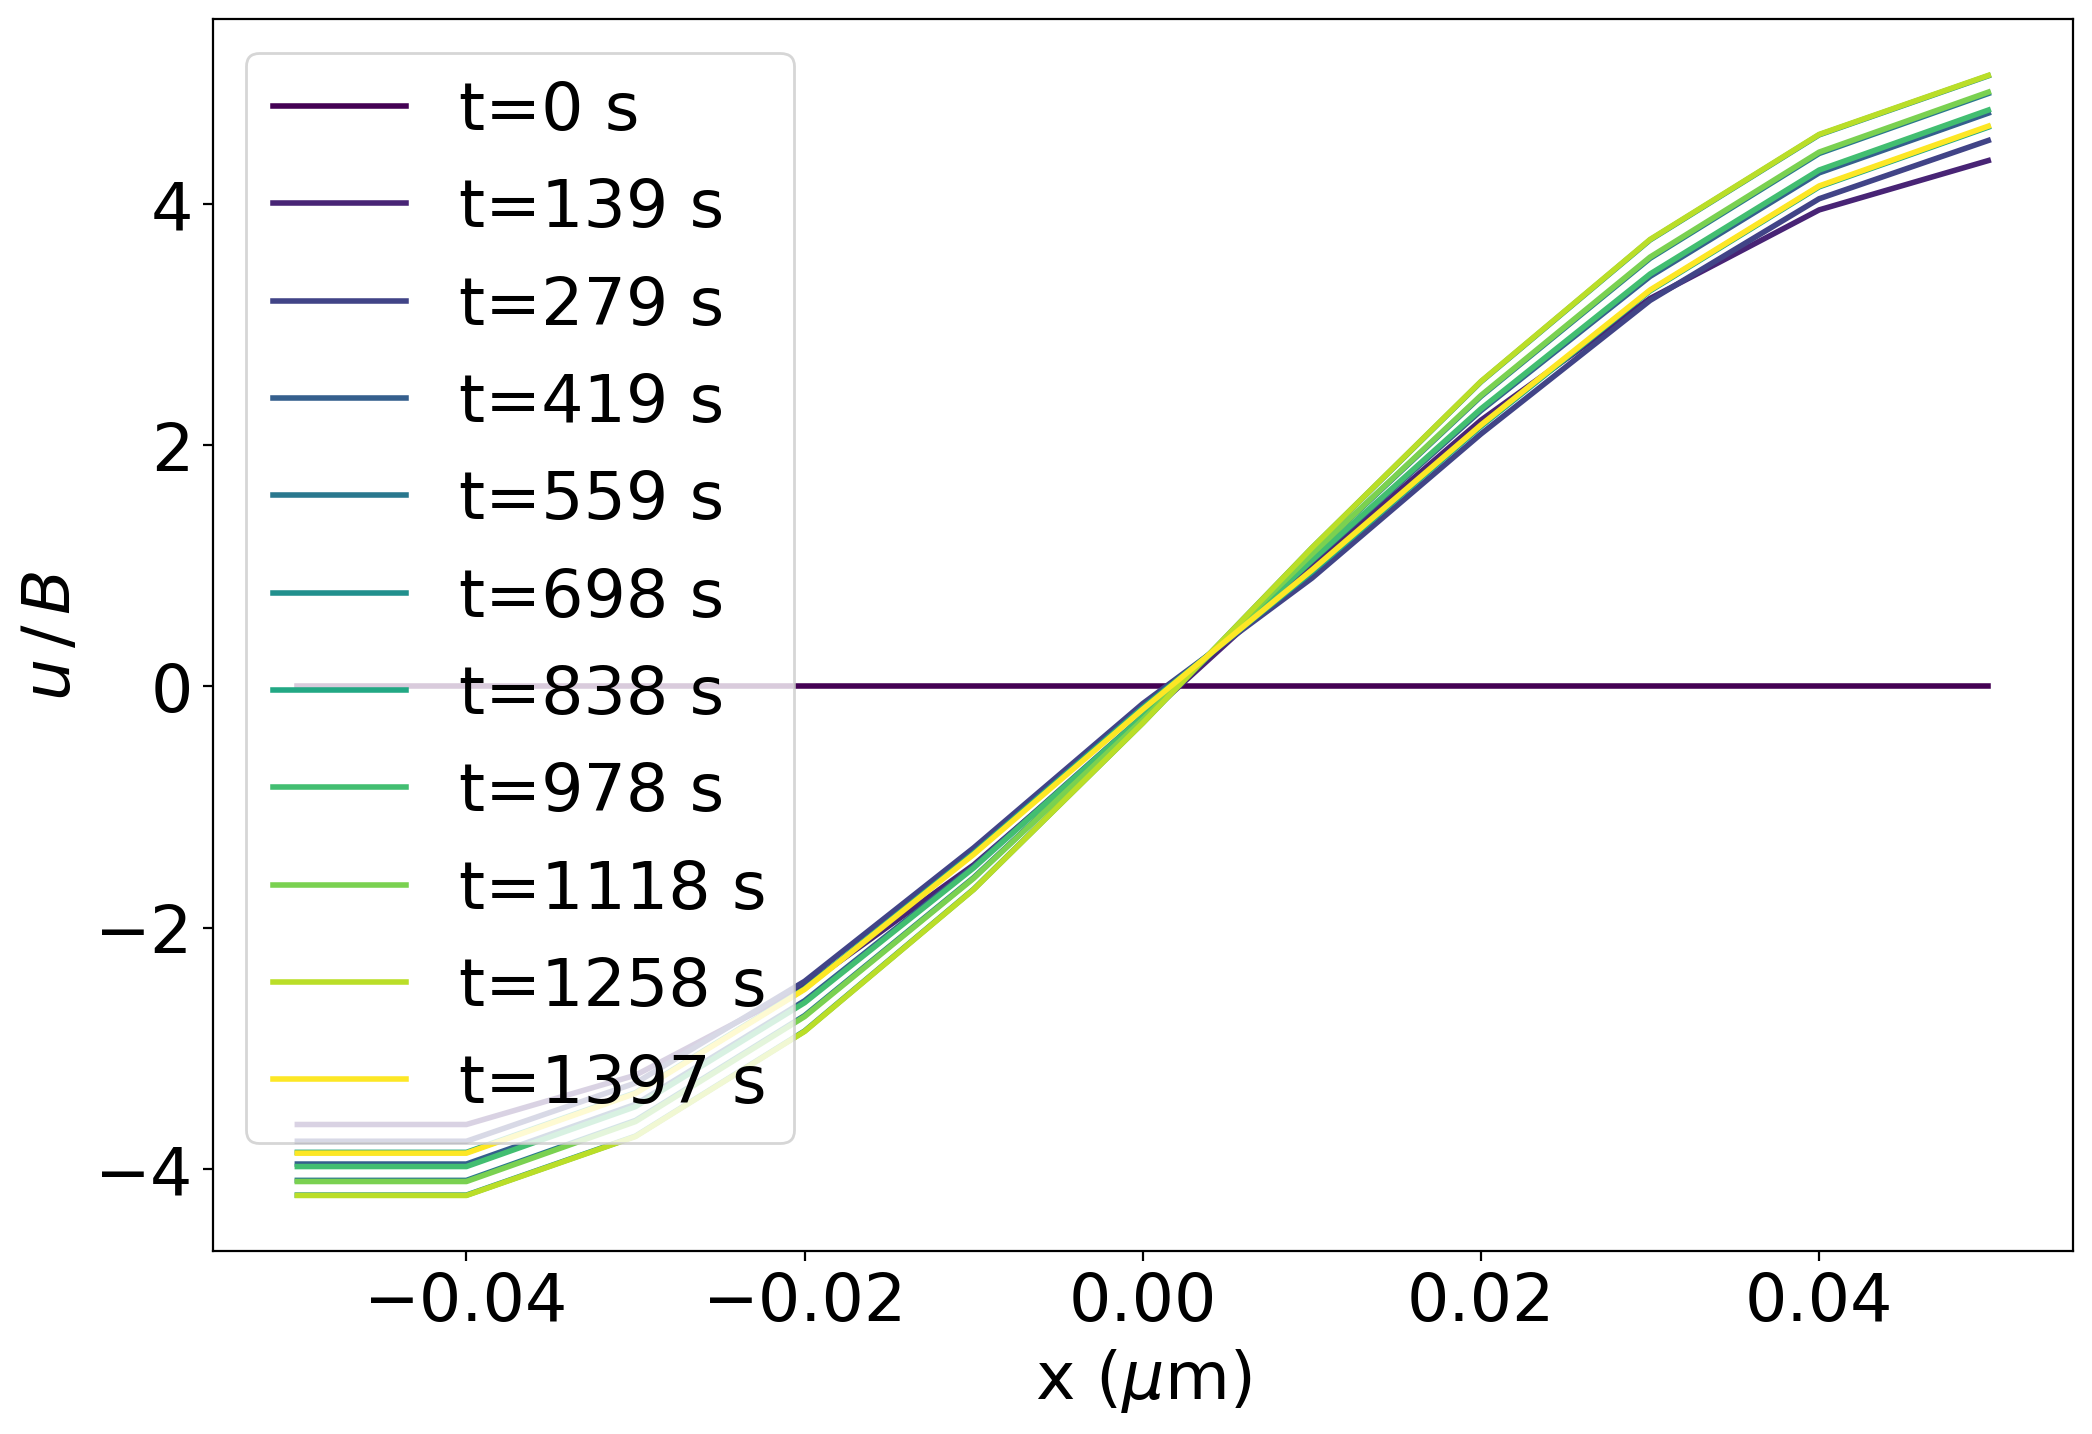

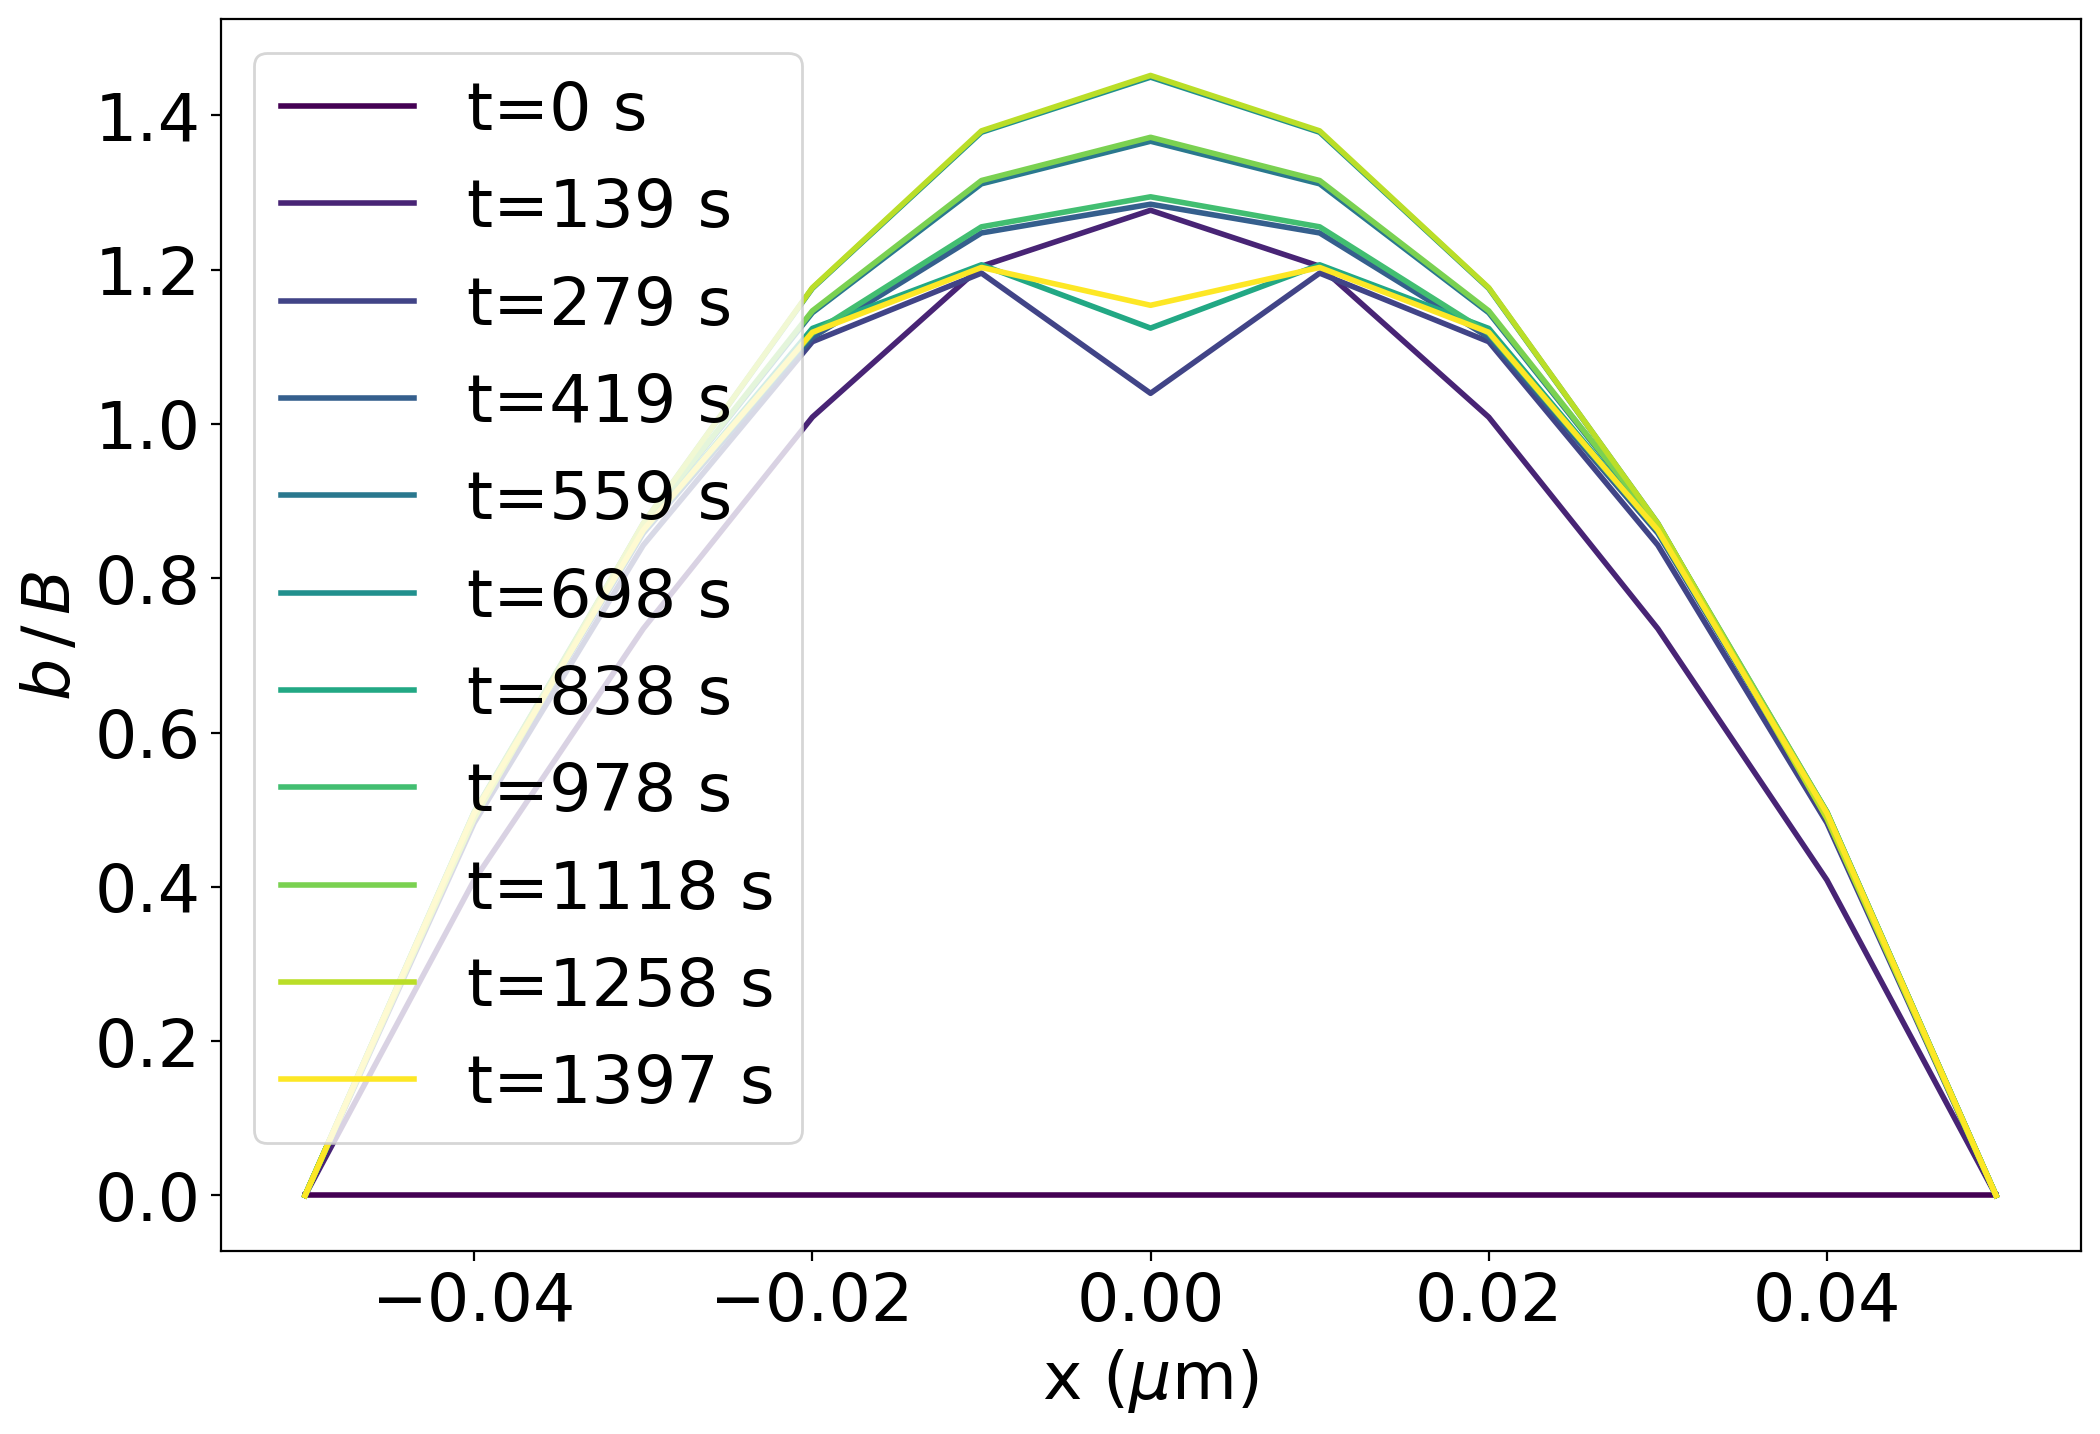

Simulation with N_gbn=21, delta=0.005, dtmax=1000.0000000000001
 Starting iteration for T, tau0, D2, Lgb, Ngbn   900.00000000000000        150.00000000000000        1.0000000000000000       0.10000000000000001               21
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)     5000000  0.52678619005332106        247.77943121259040        1.8981551550653928E-009   2.4359379065316427E-003          13          21  0.97667130253679313     
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)    10000000  0.58356781755603737        487.51456434737190        1.7134505688742390E-009   2.5217570901797837E-003          13          41  0.92652379207908242     
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)    15000000  0.58668564076038732        727.55403919062815        1.7043441005515936E-009   2.5260364467347657E-003          13          61  0.92404046531135209     
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)    2000

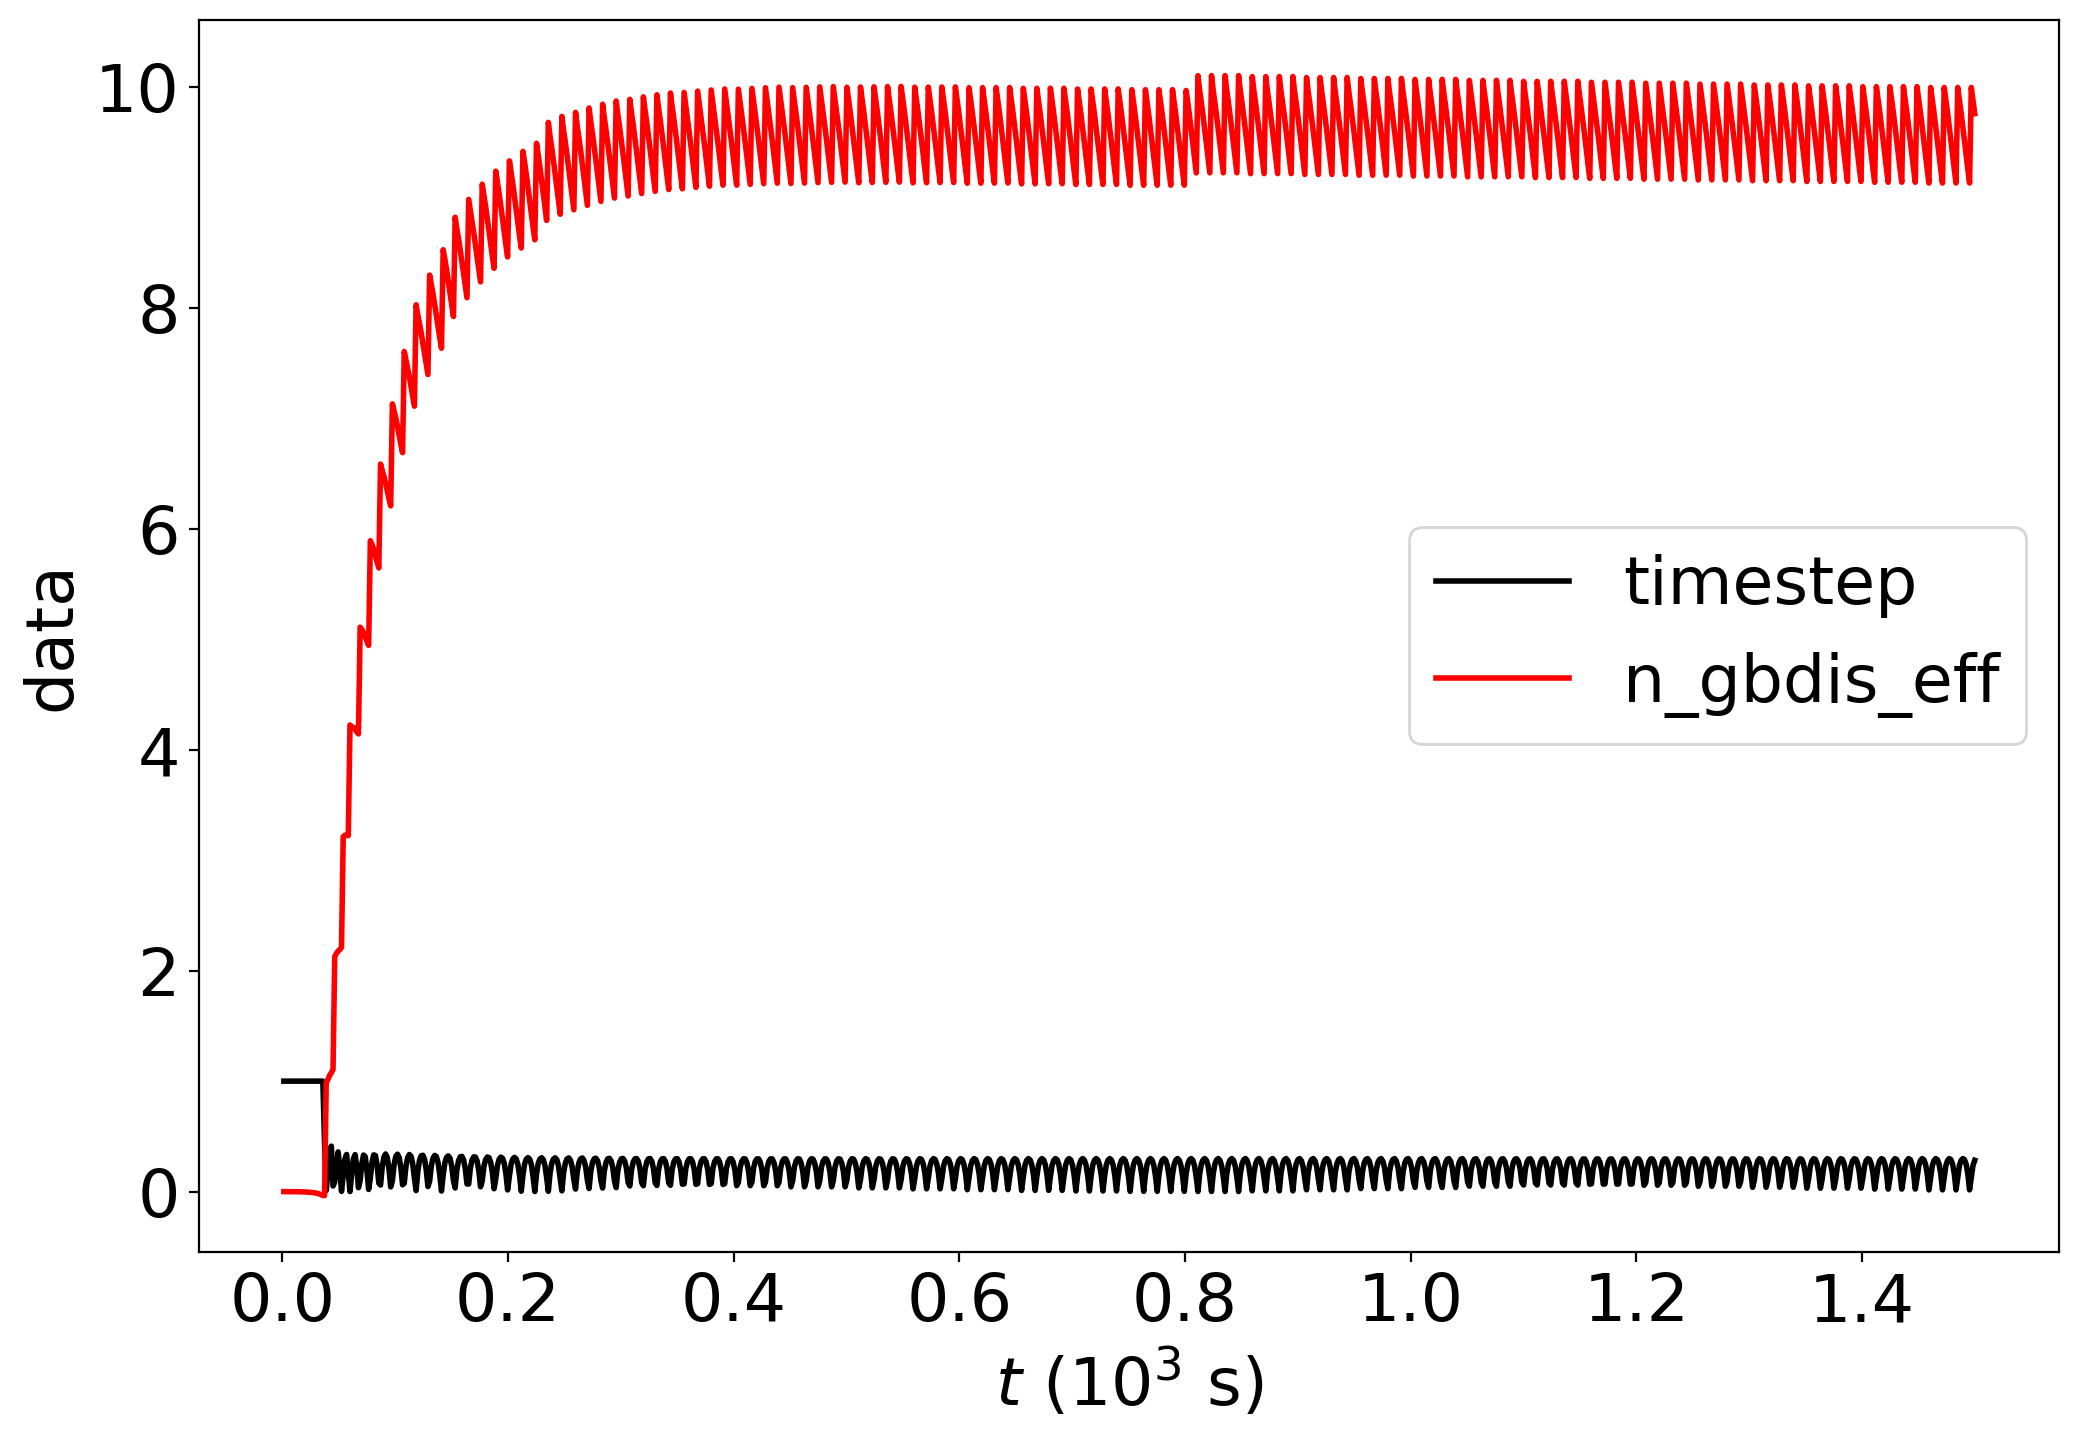

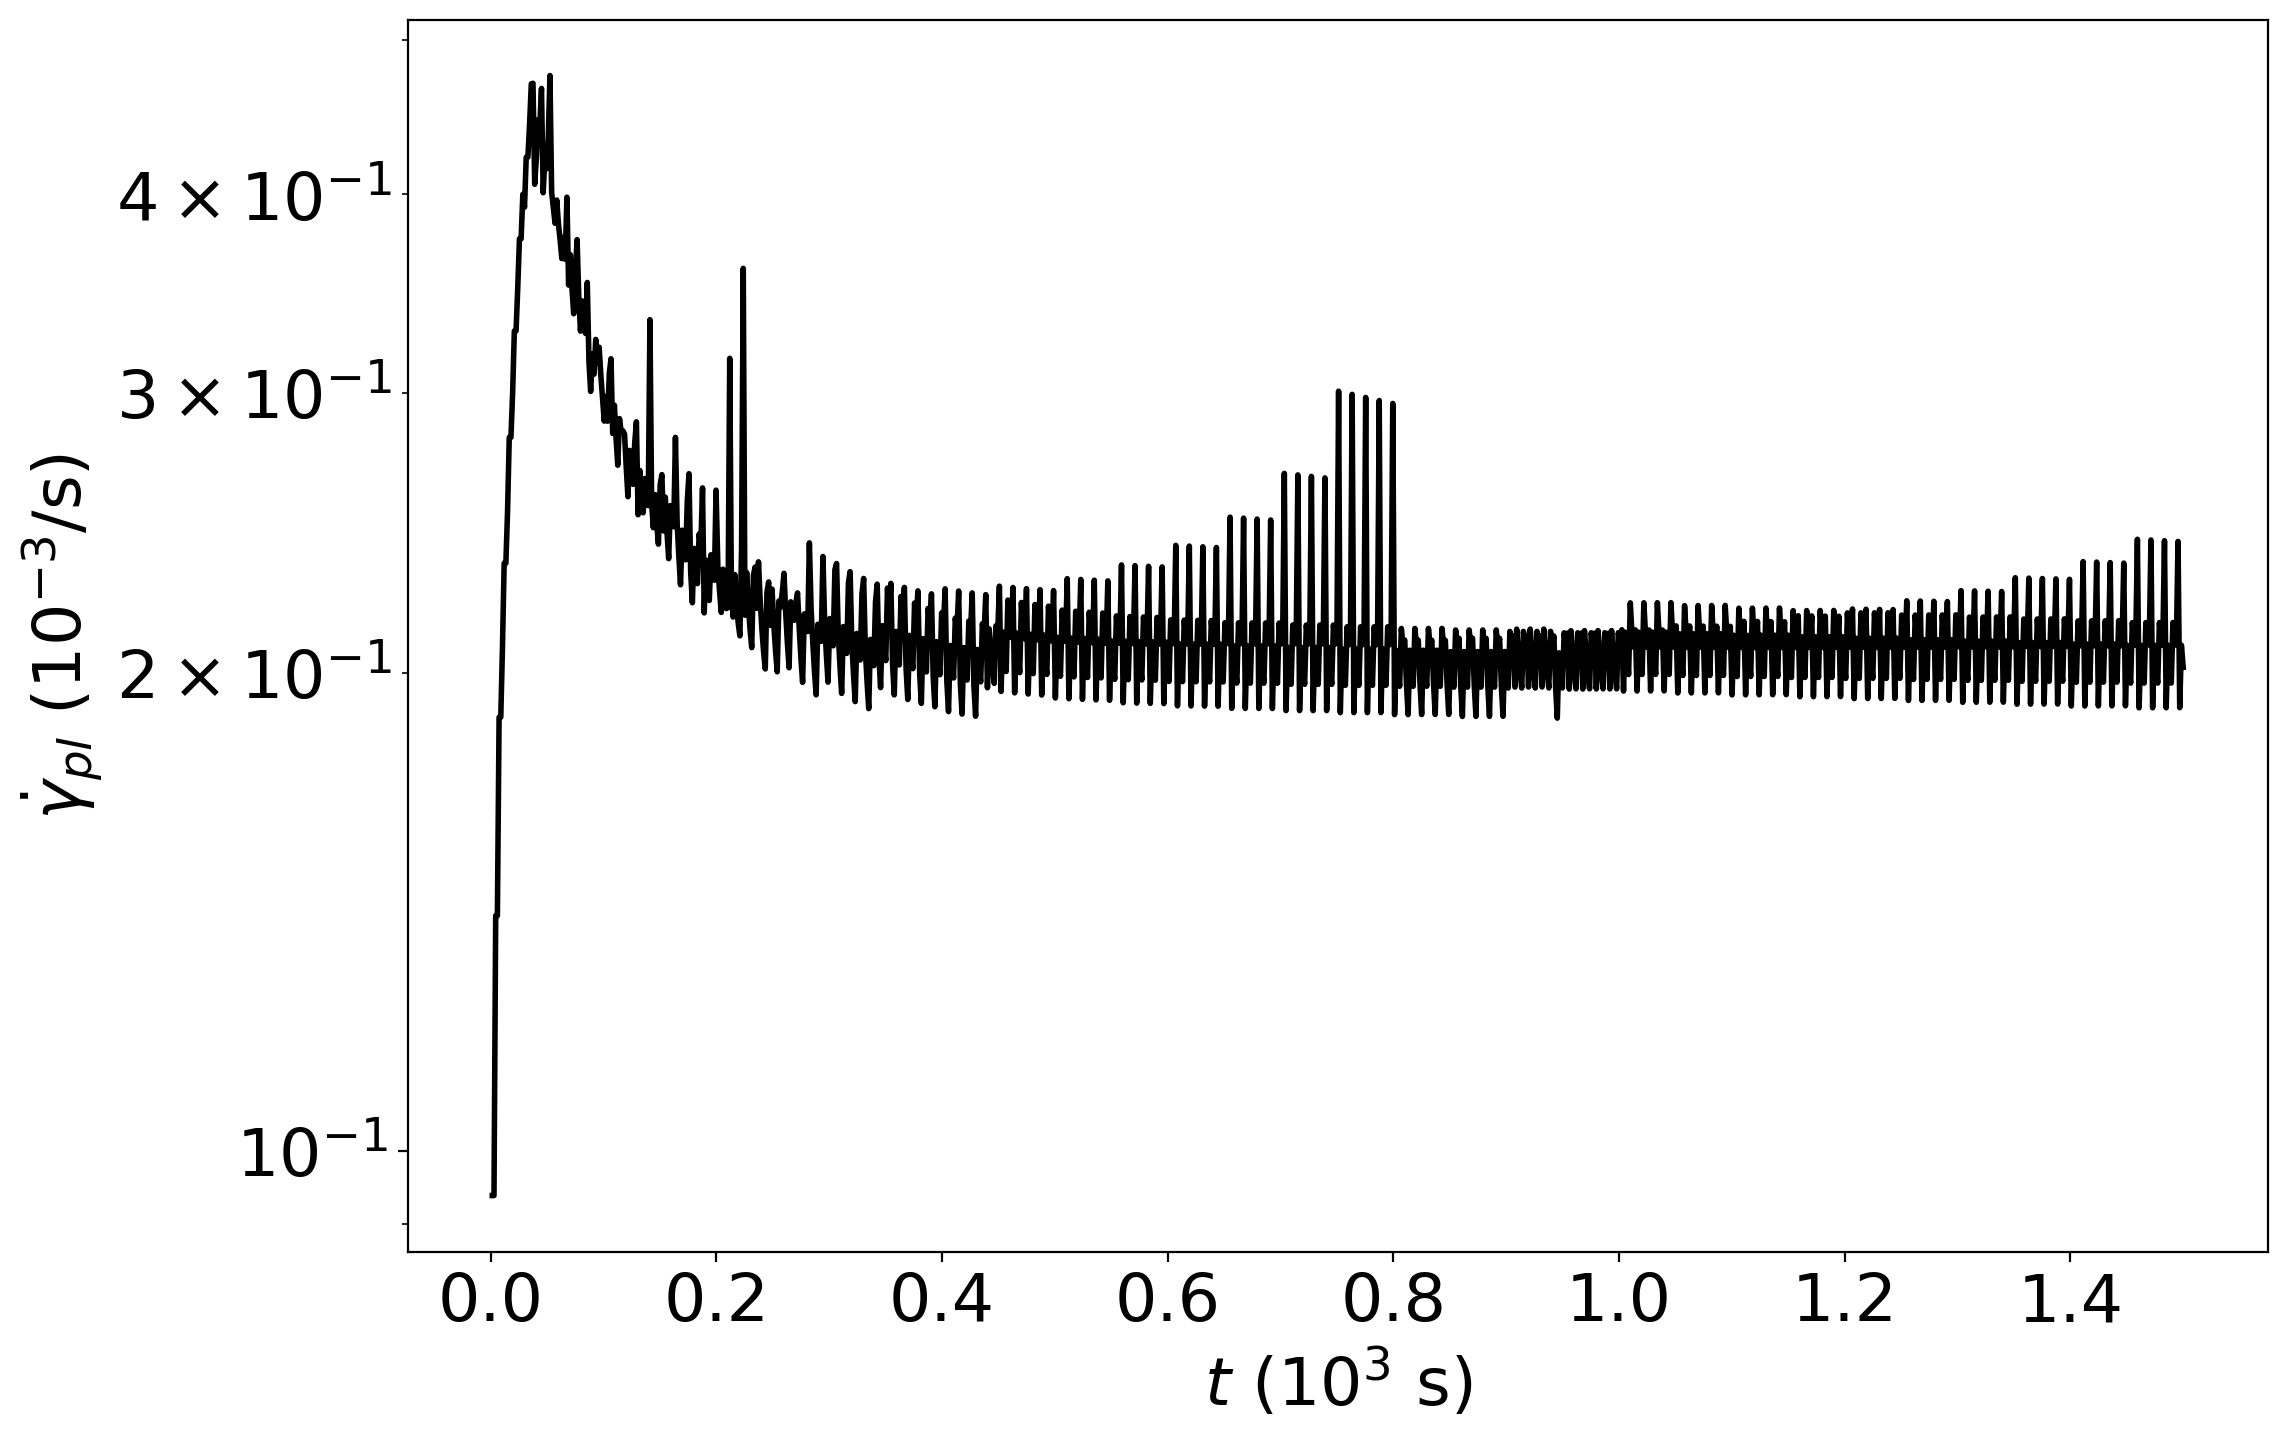

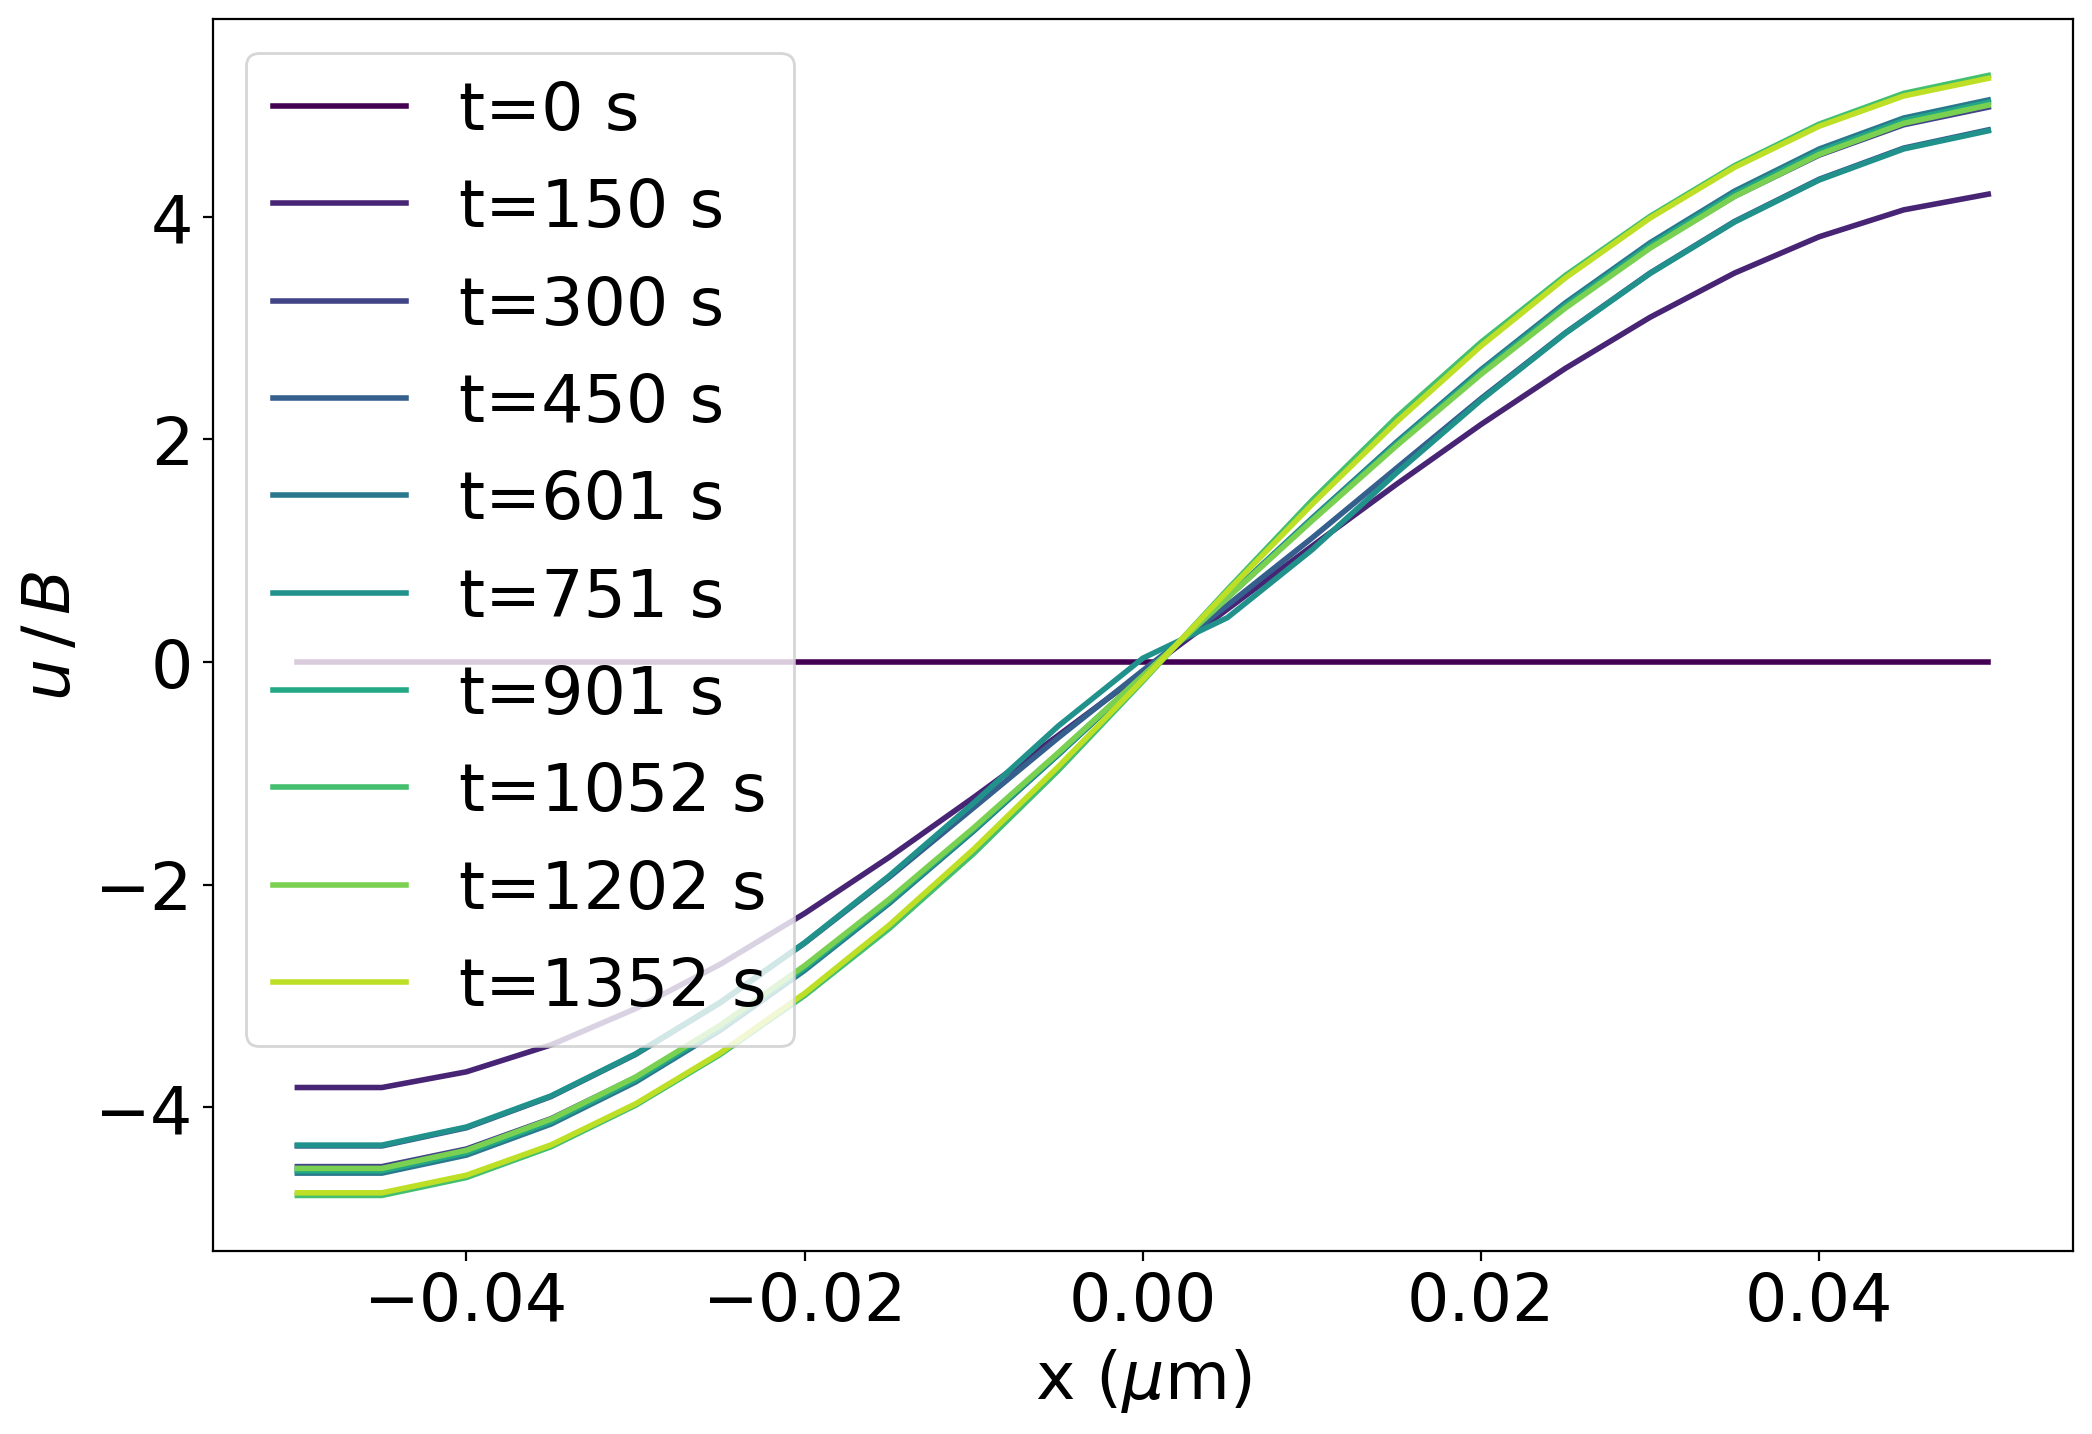

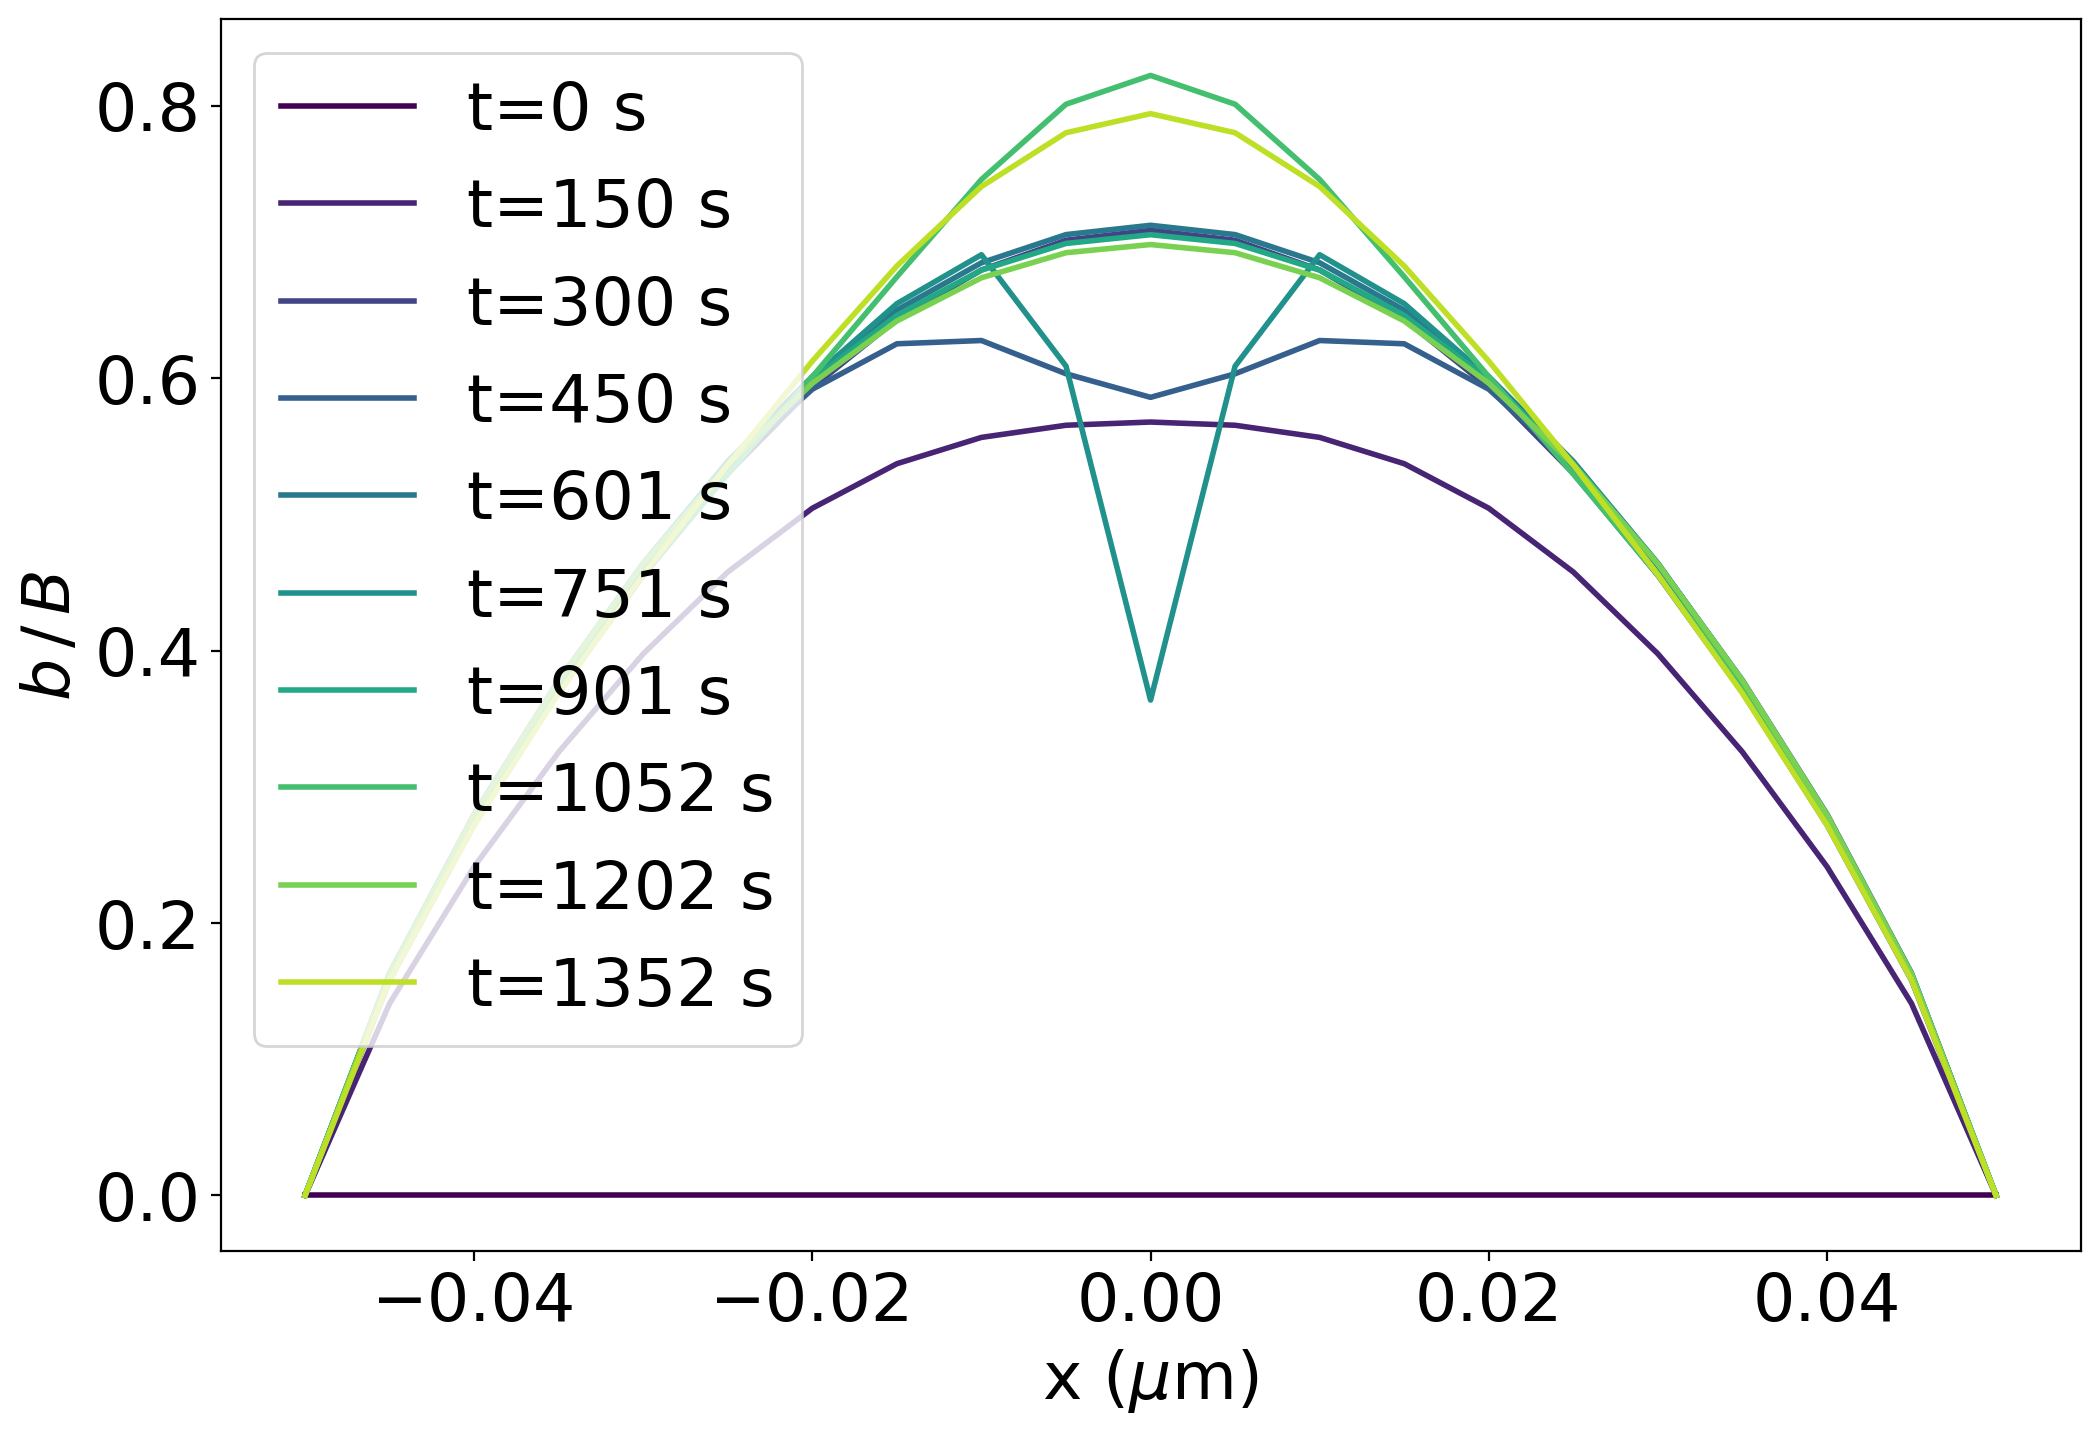

Simulation with N_gbn=31, delta=0.0033333333333333335, dtmax=5062.5
 Starting iteration for T, tau0, D2, Lgb, Ngbn   900.00000000000000        150.00000000000000        1.0000000000000000       0.10000000000000001               31
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)     5000000  0.94672775160647182        1252.9501229747314        5.3451570655657620E-009   2.5781093869455748E-003          13         102  0.91228937949862776     


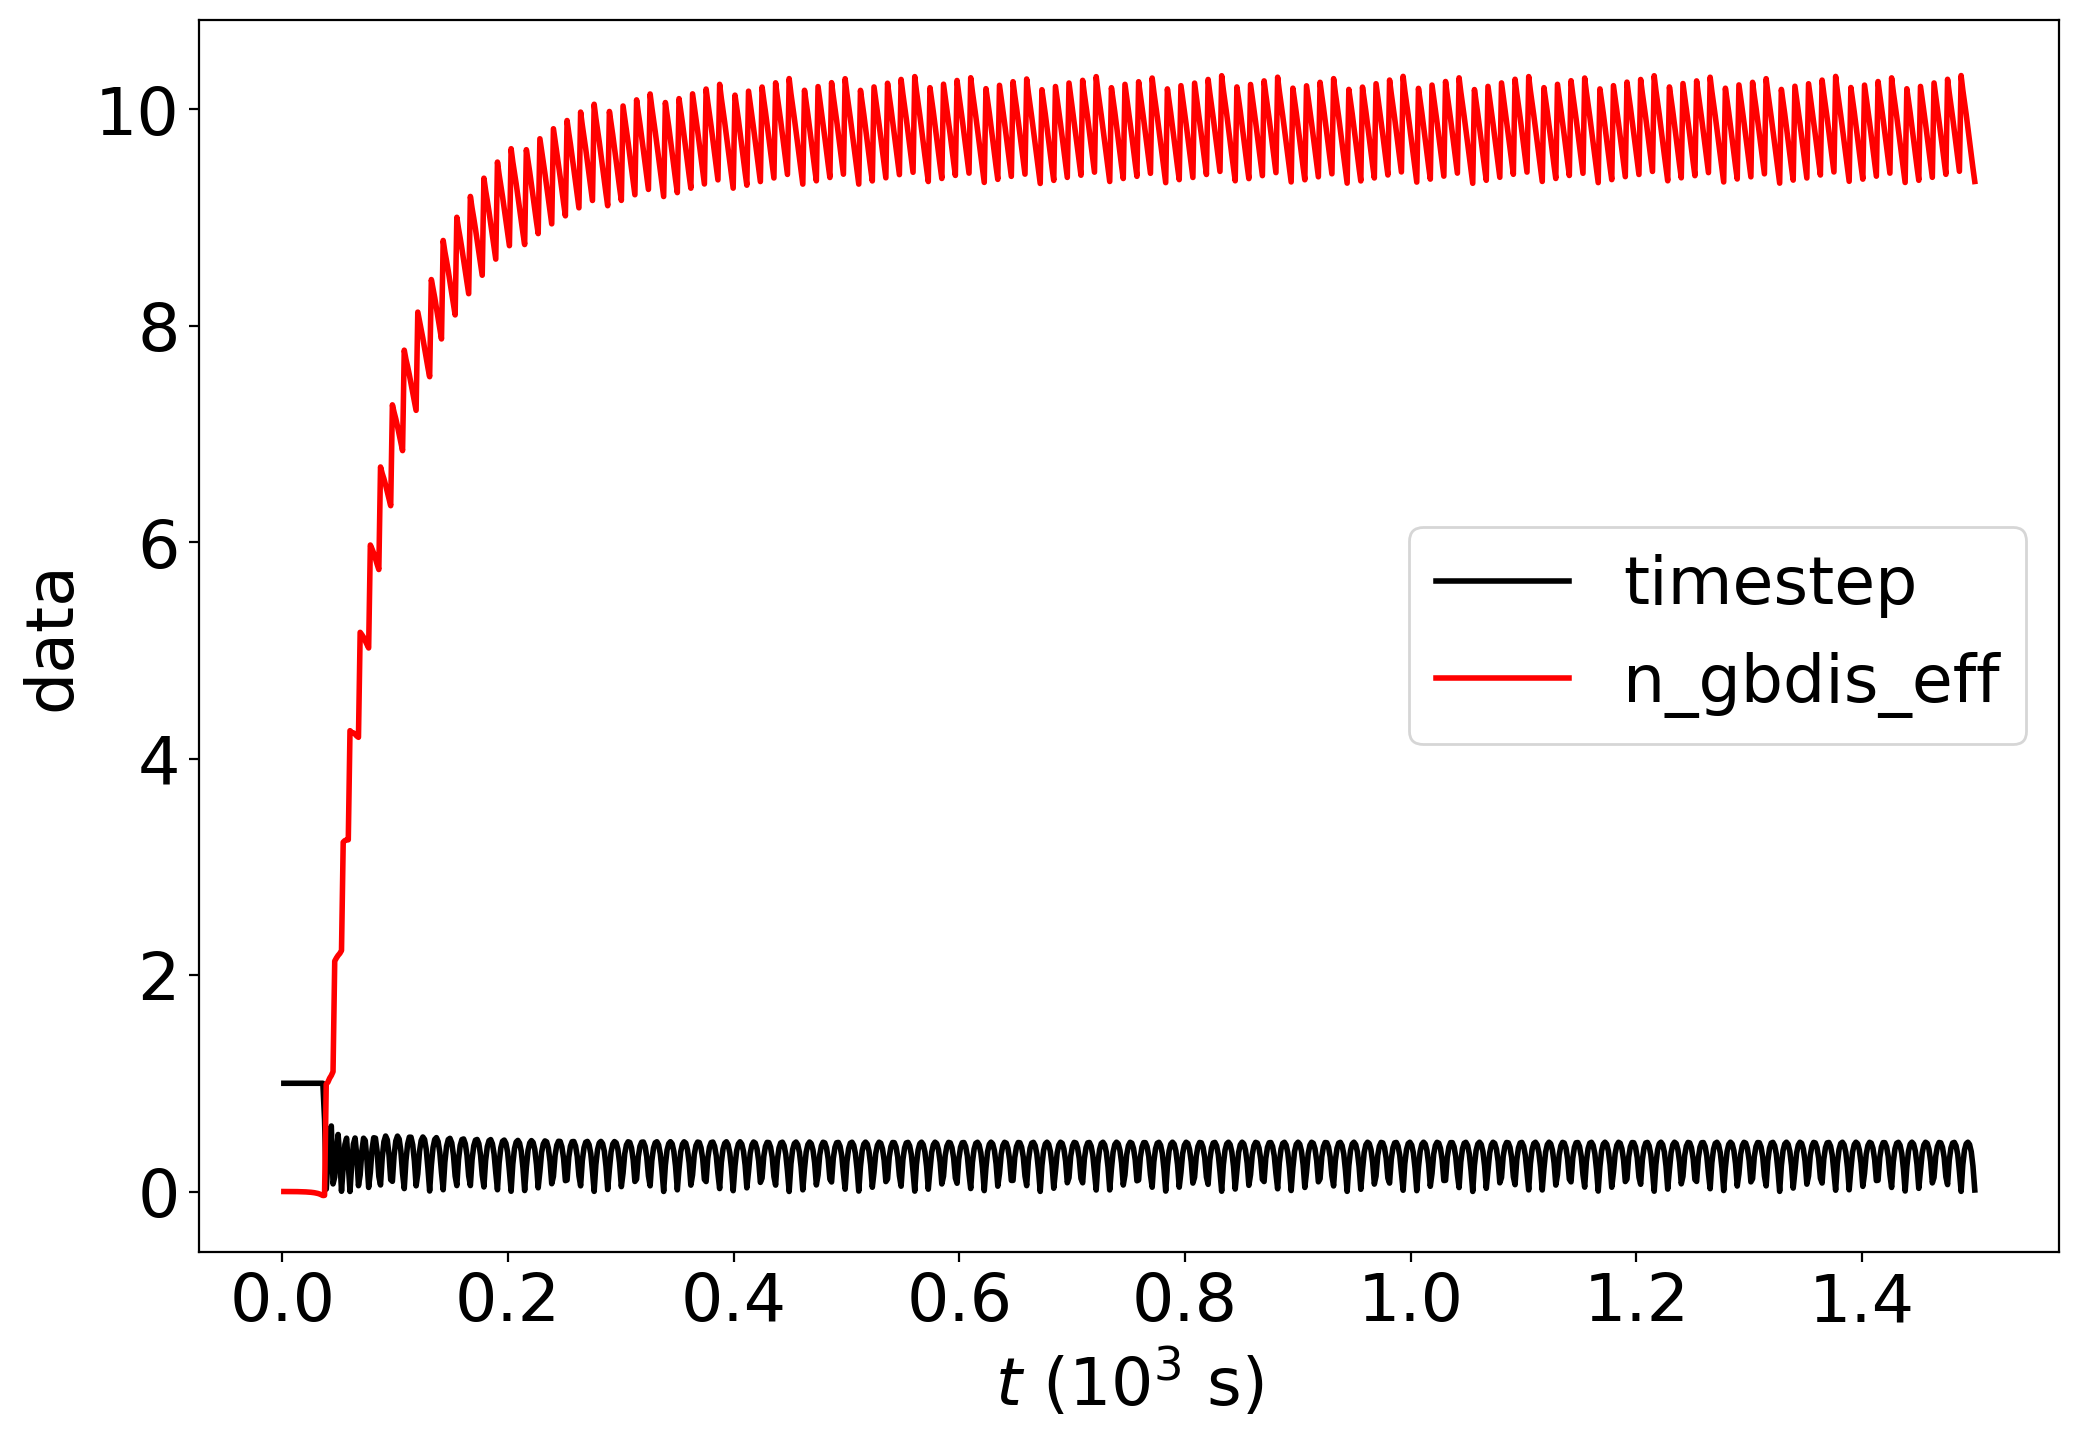

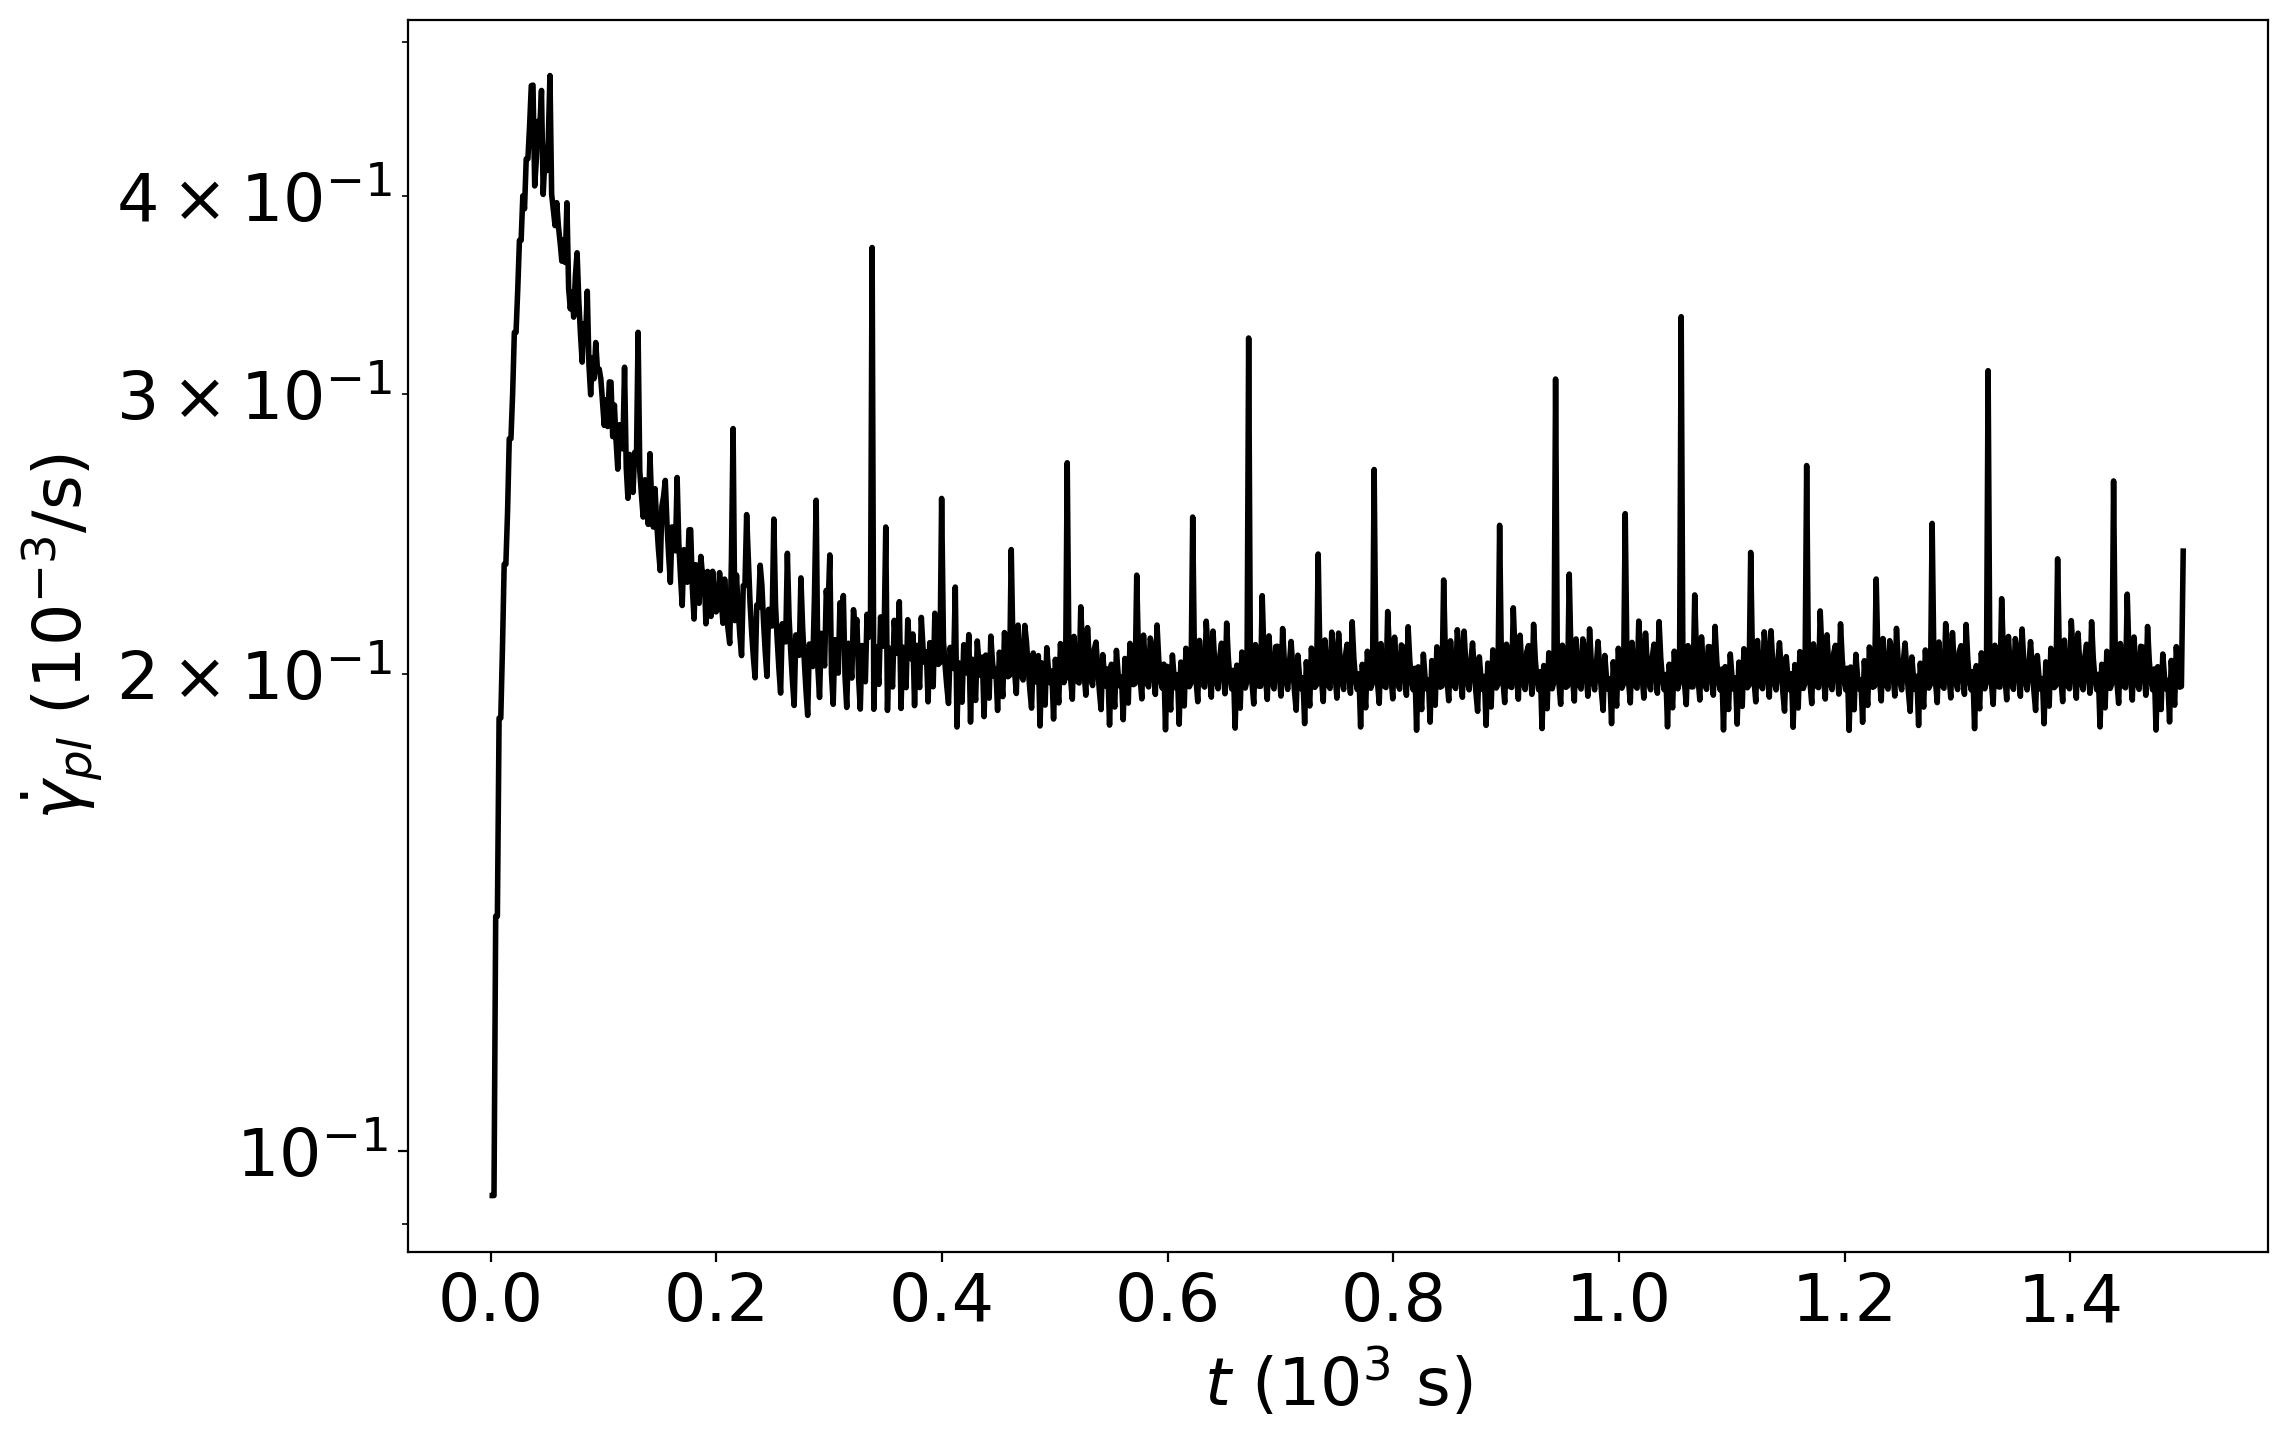

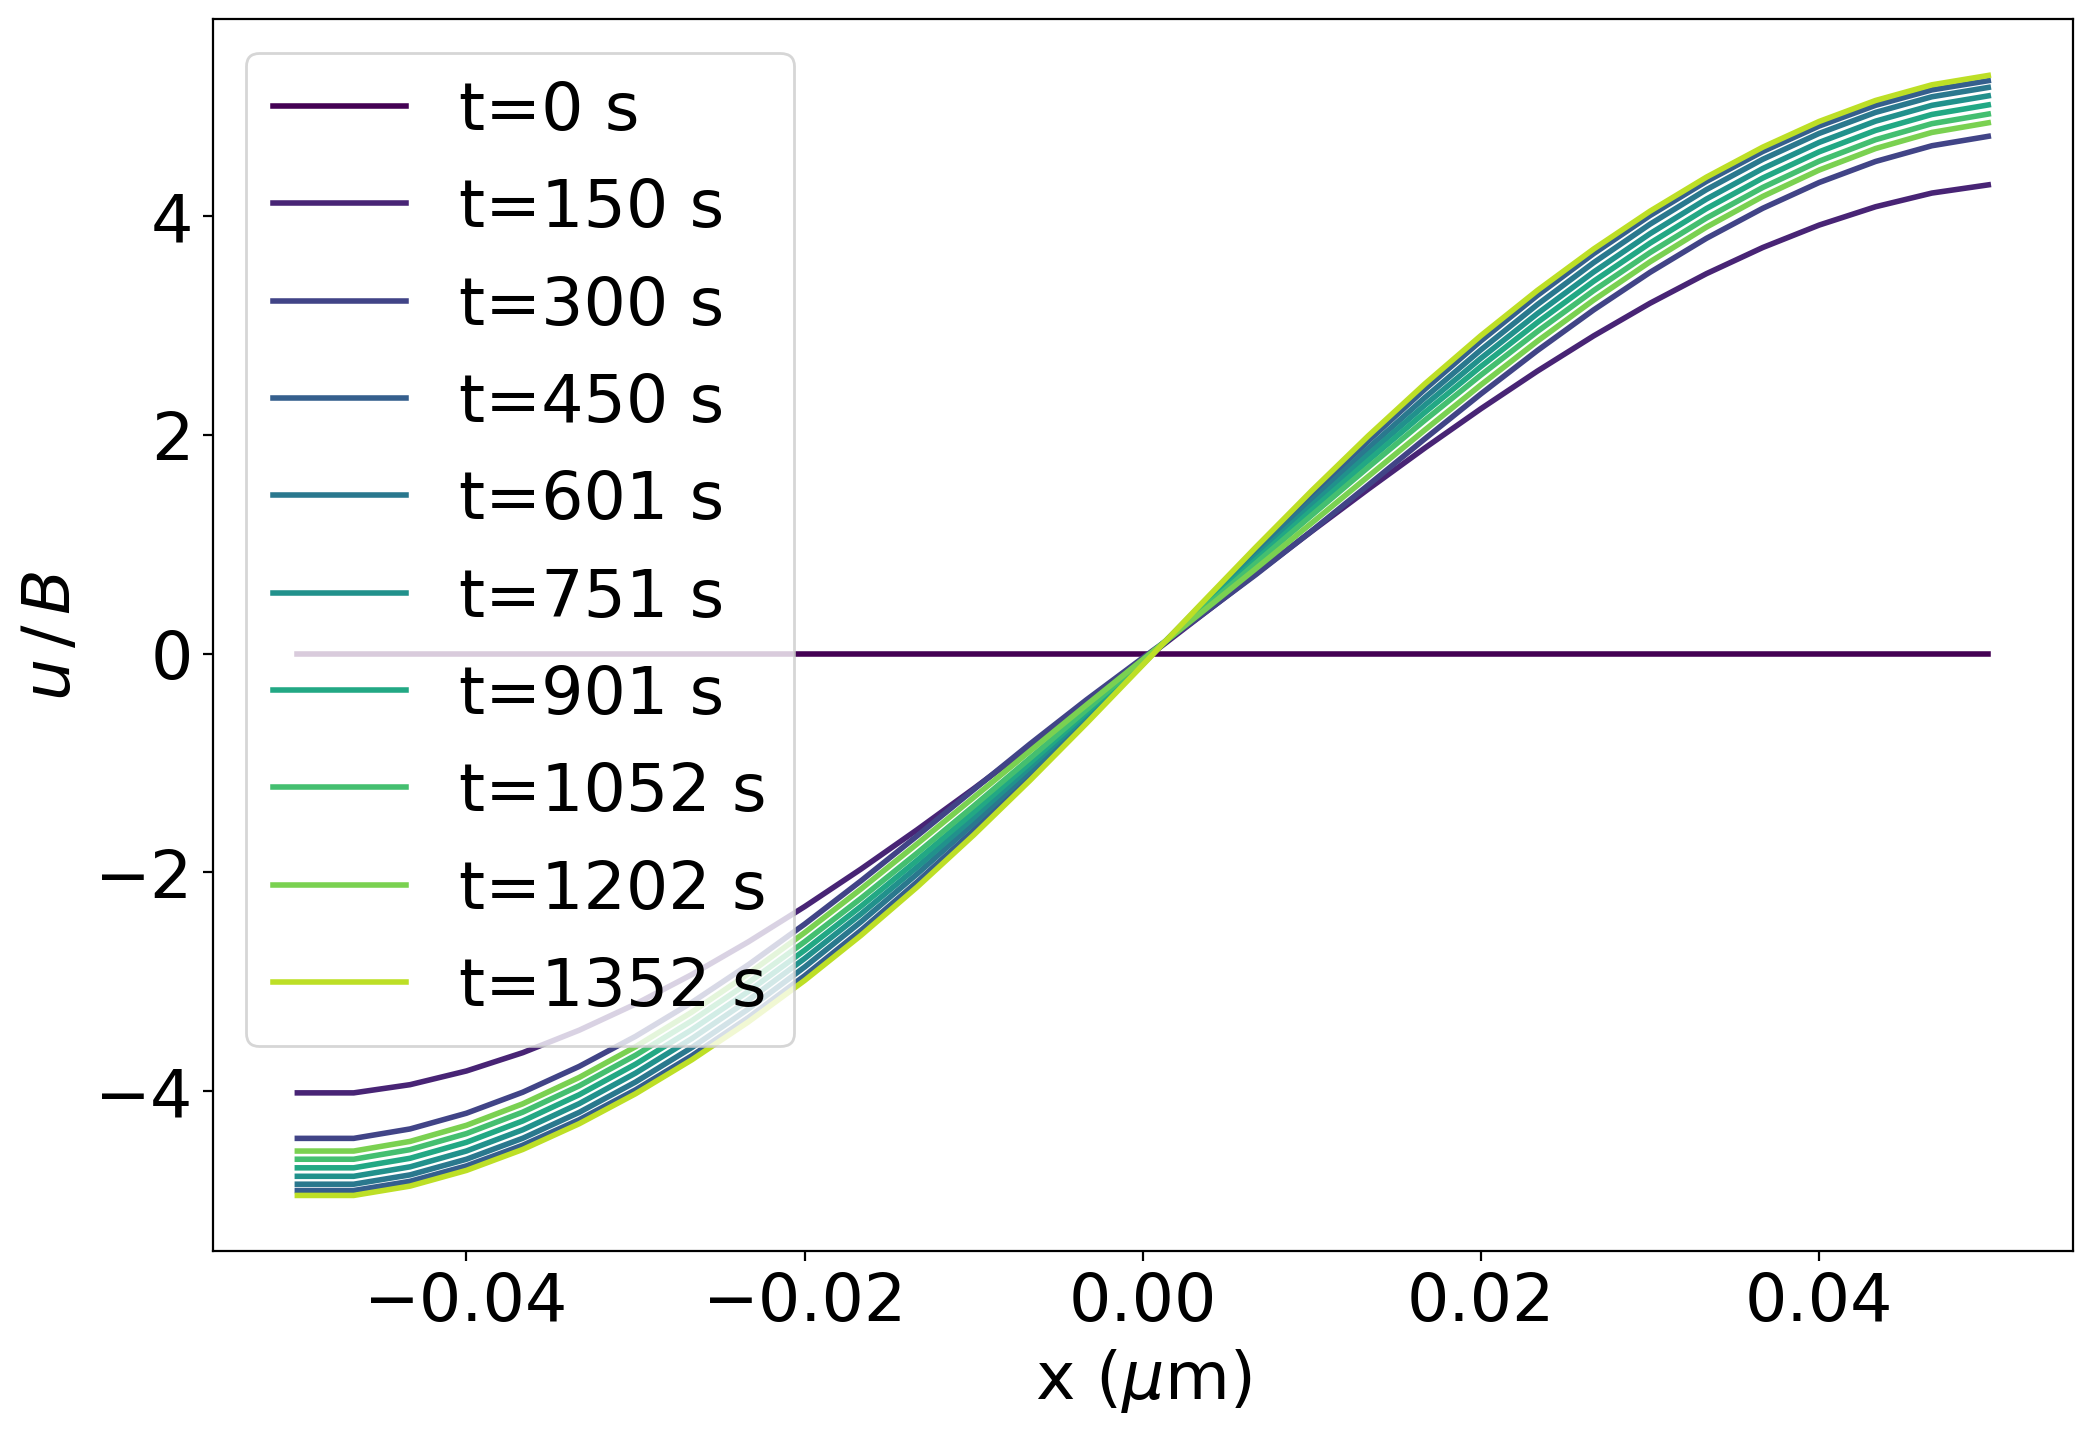

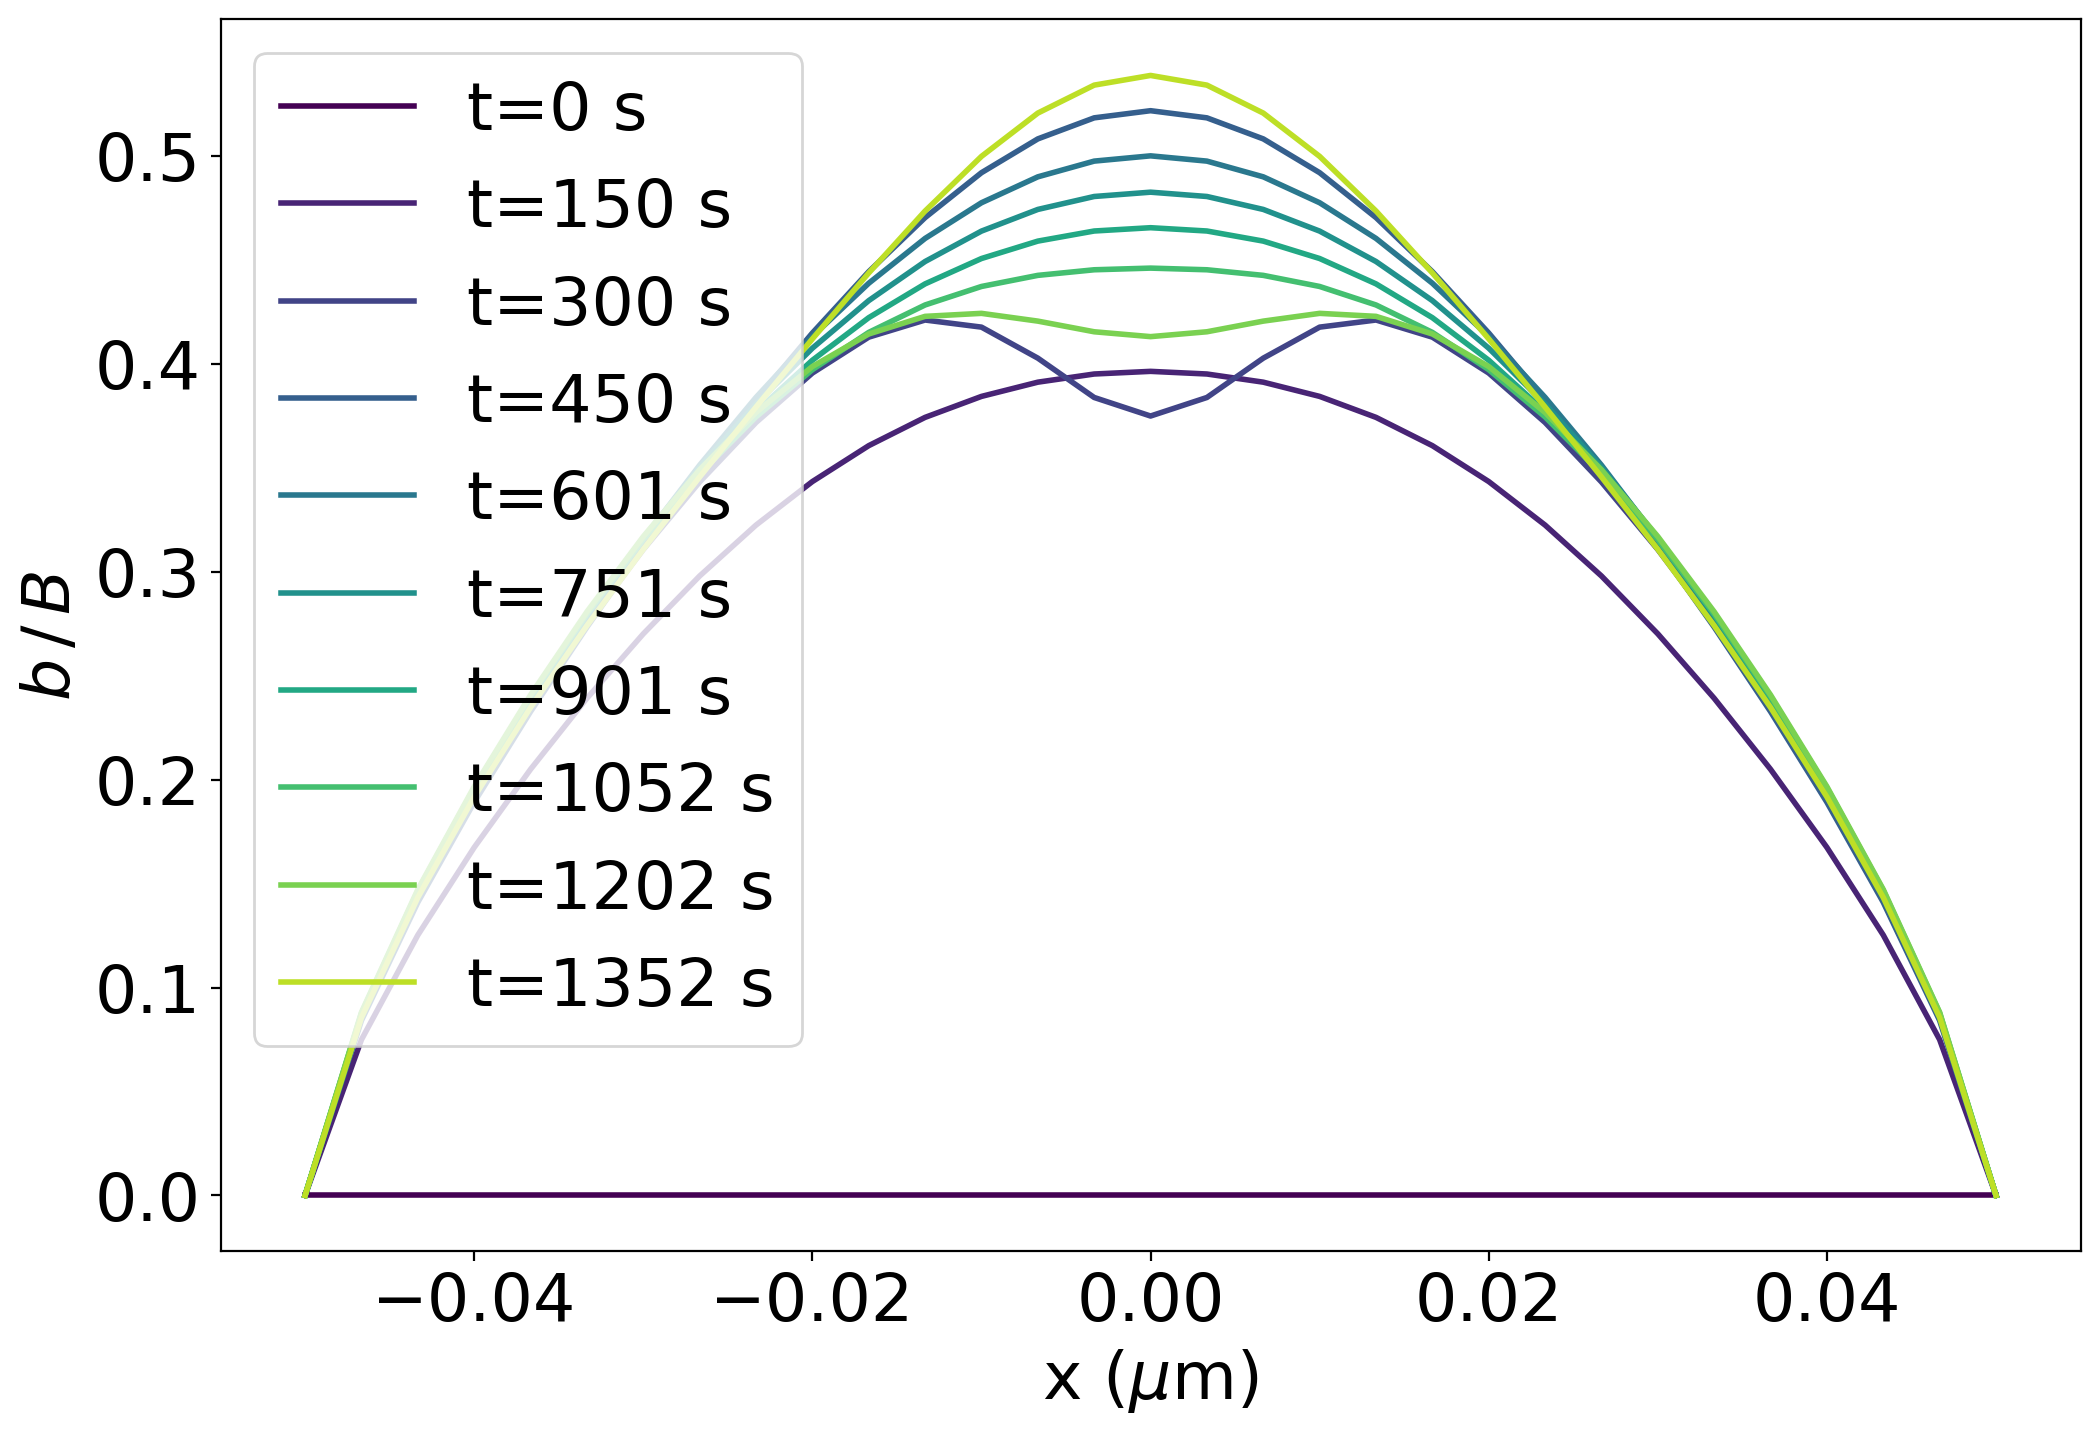

Simulation with N_gbn=41, delta=0.0025, dtmax=16000.000000000002
 Starting iteration for T, tau0, D2, Lgb, Ngbn   900.00000000000000        150.00000000000000        1.0000000000000000       0.10000000000000001               41


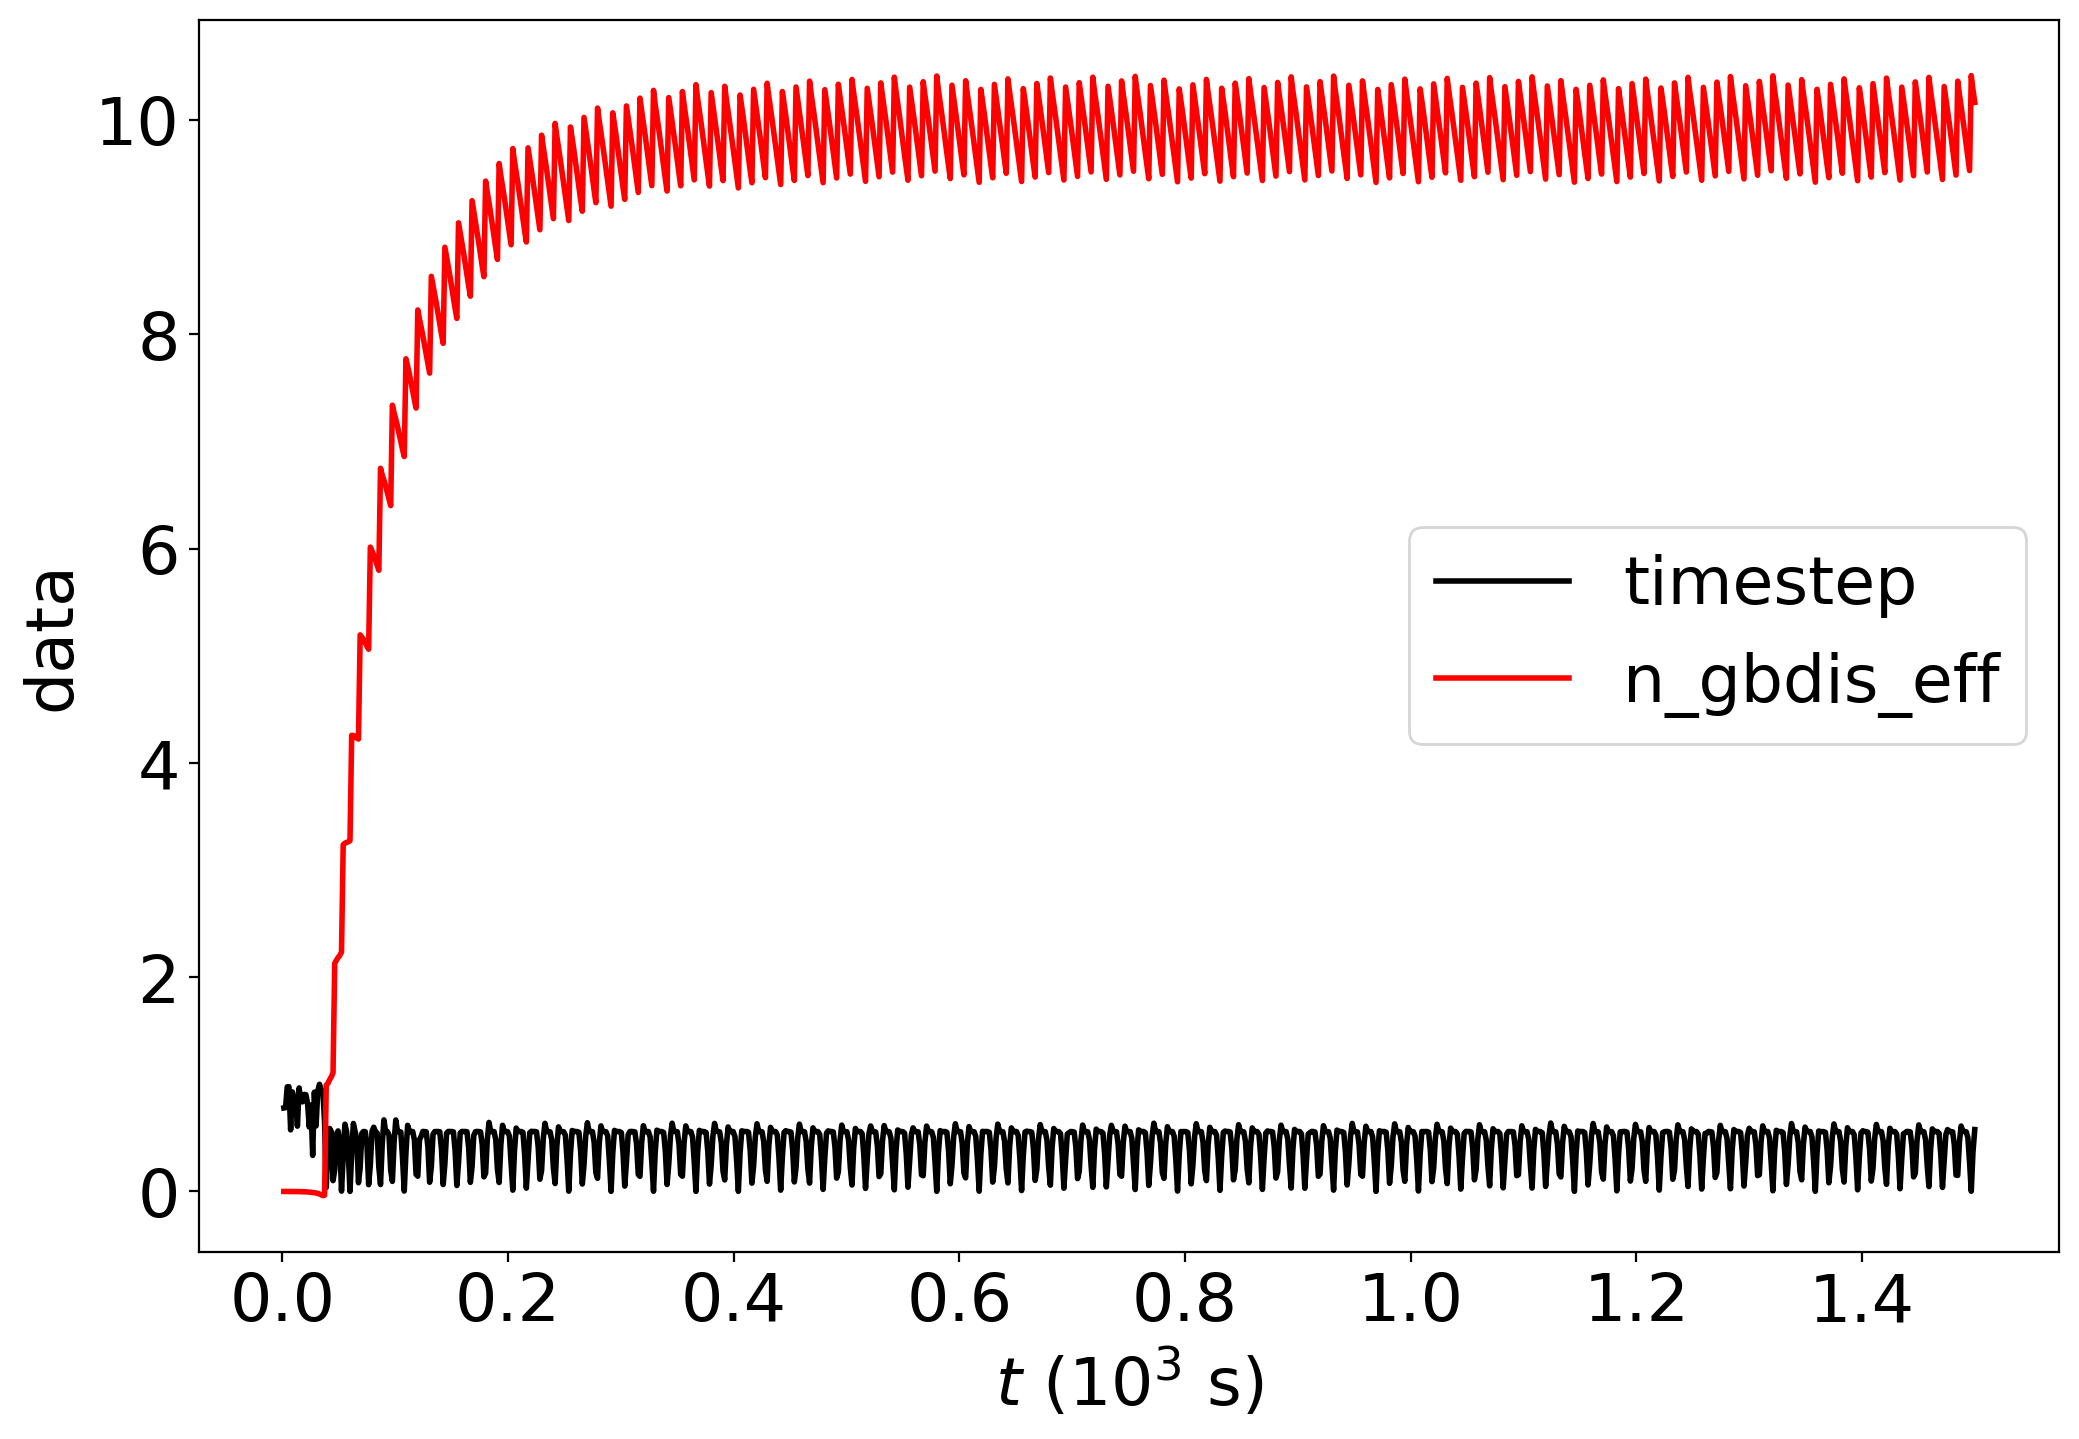

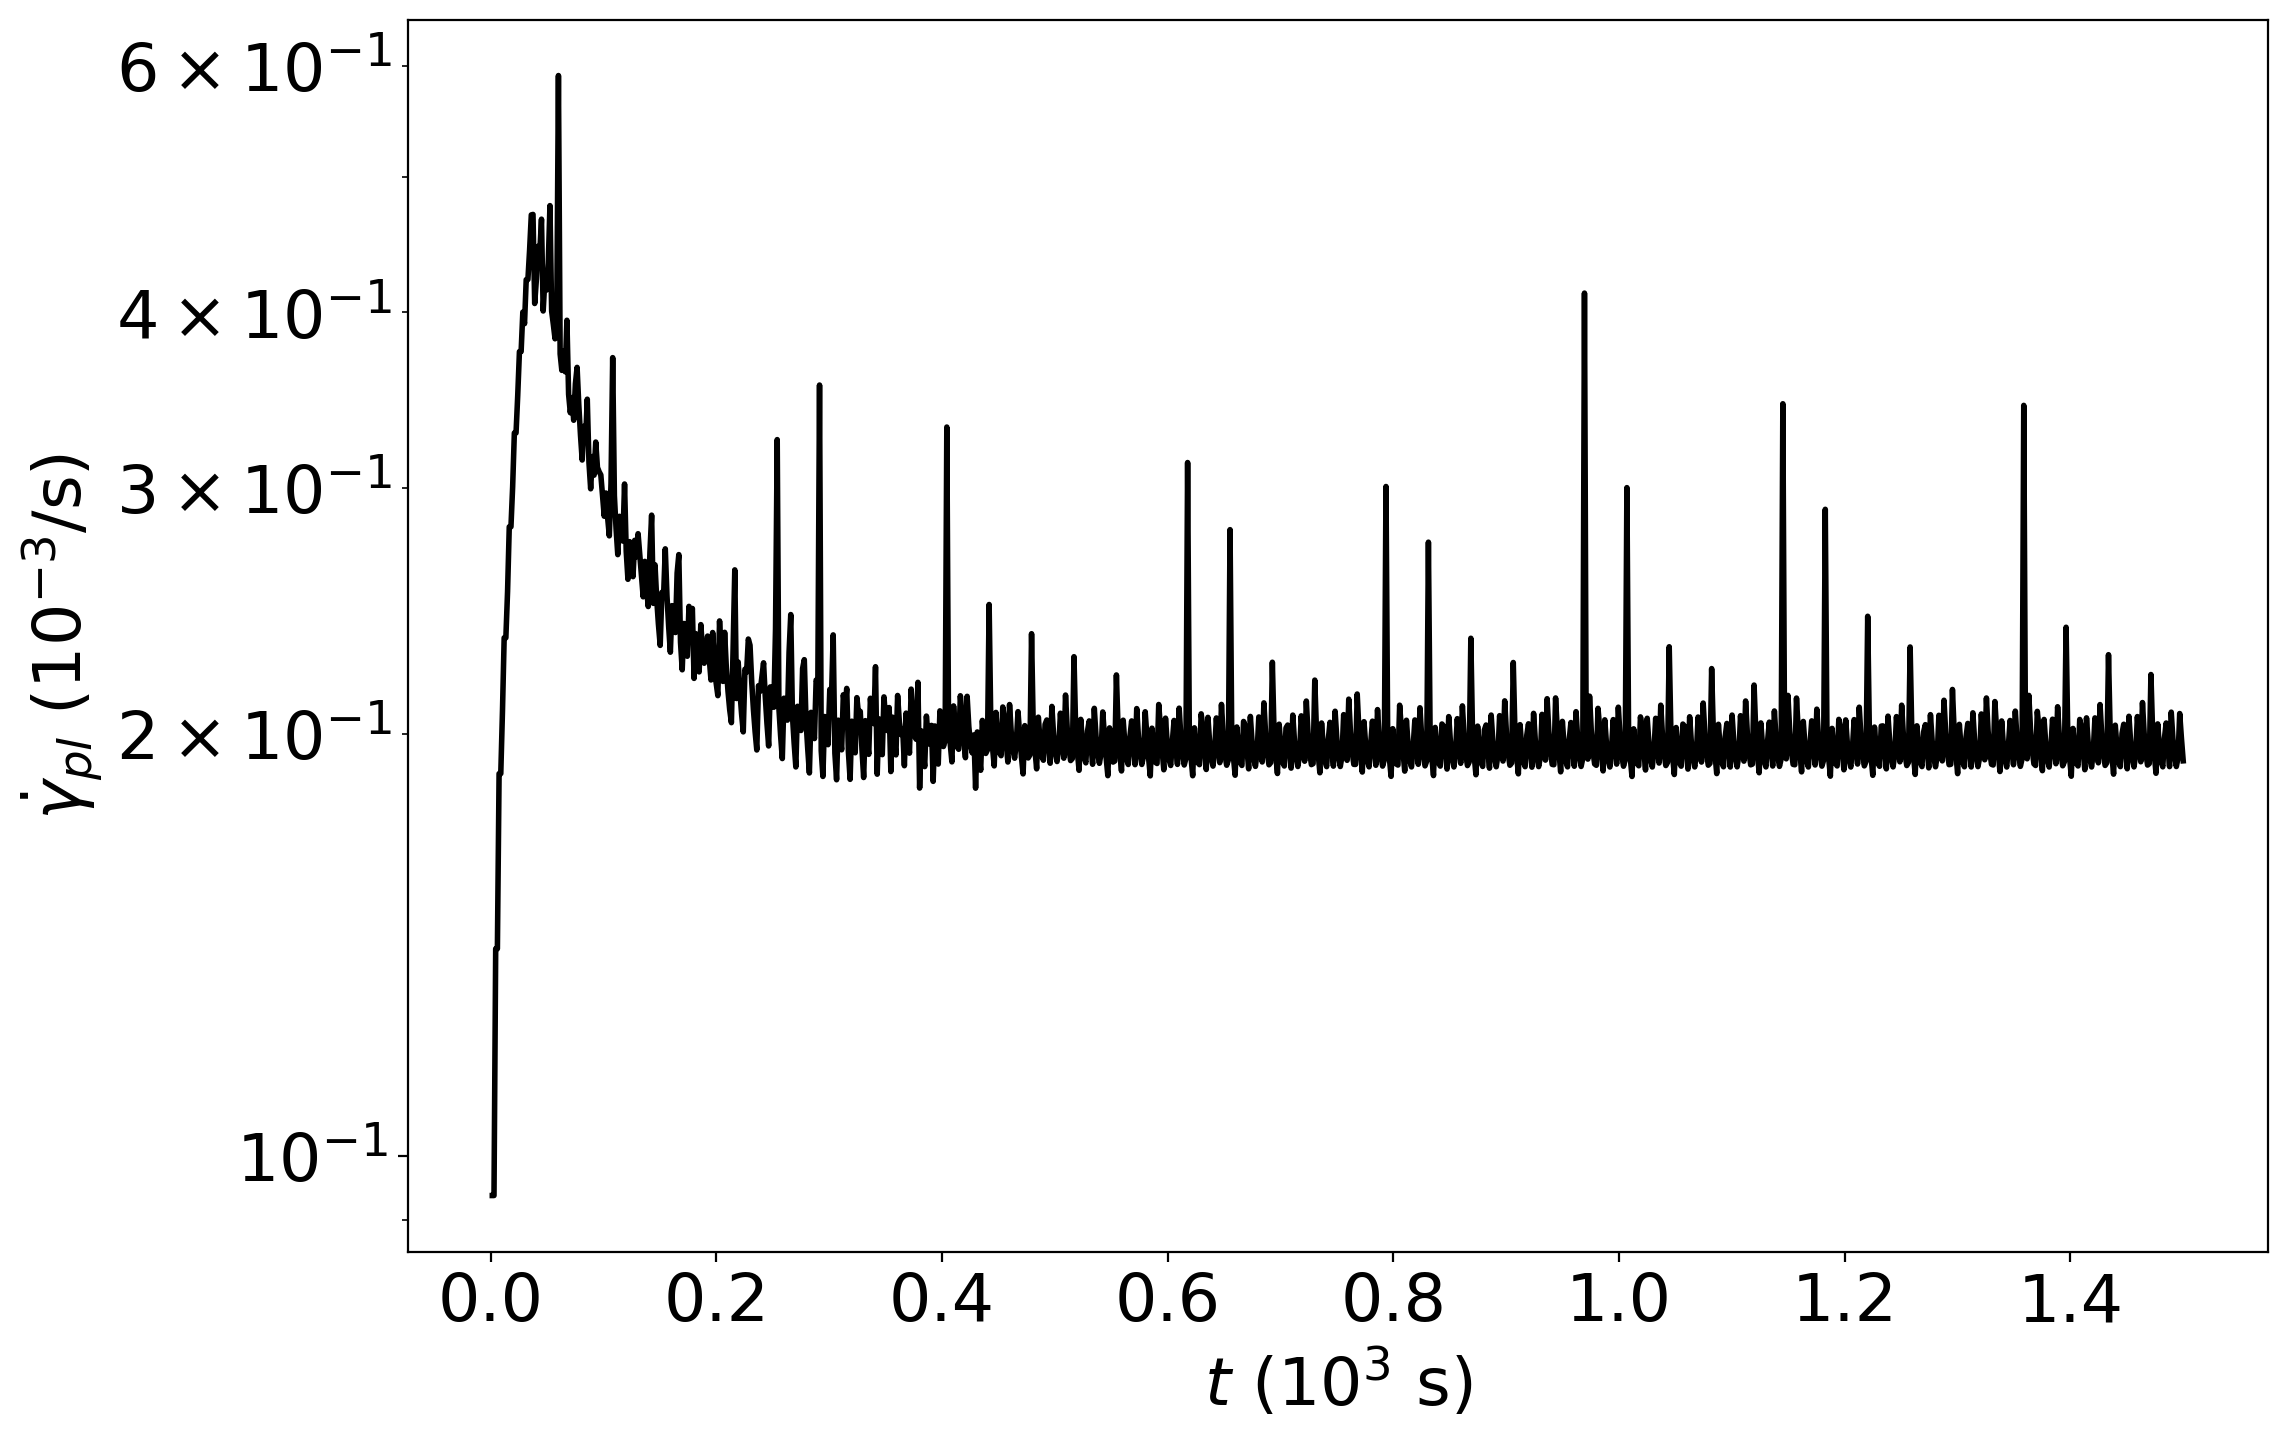

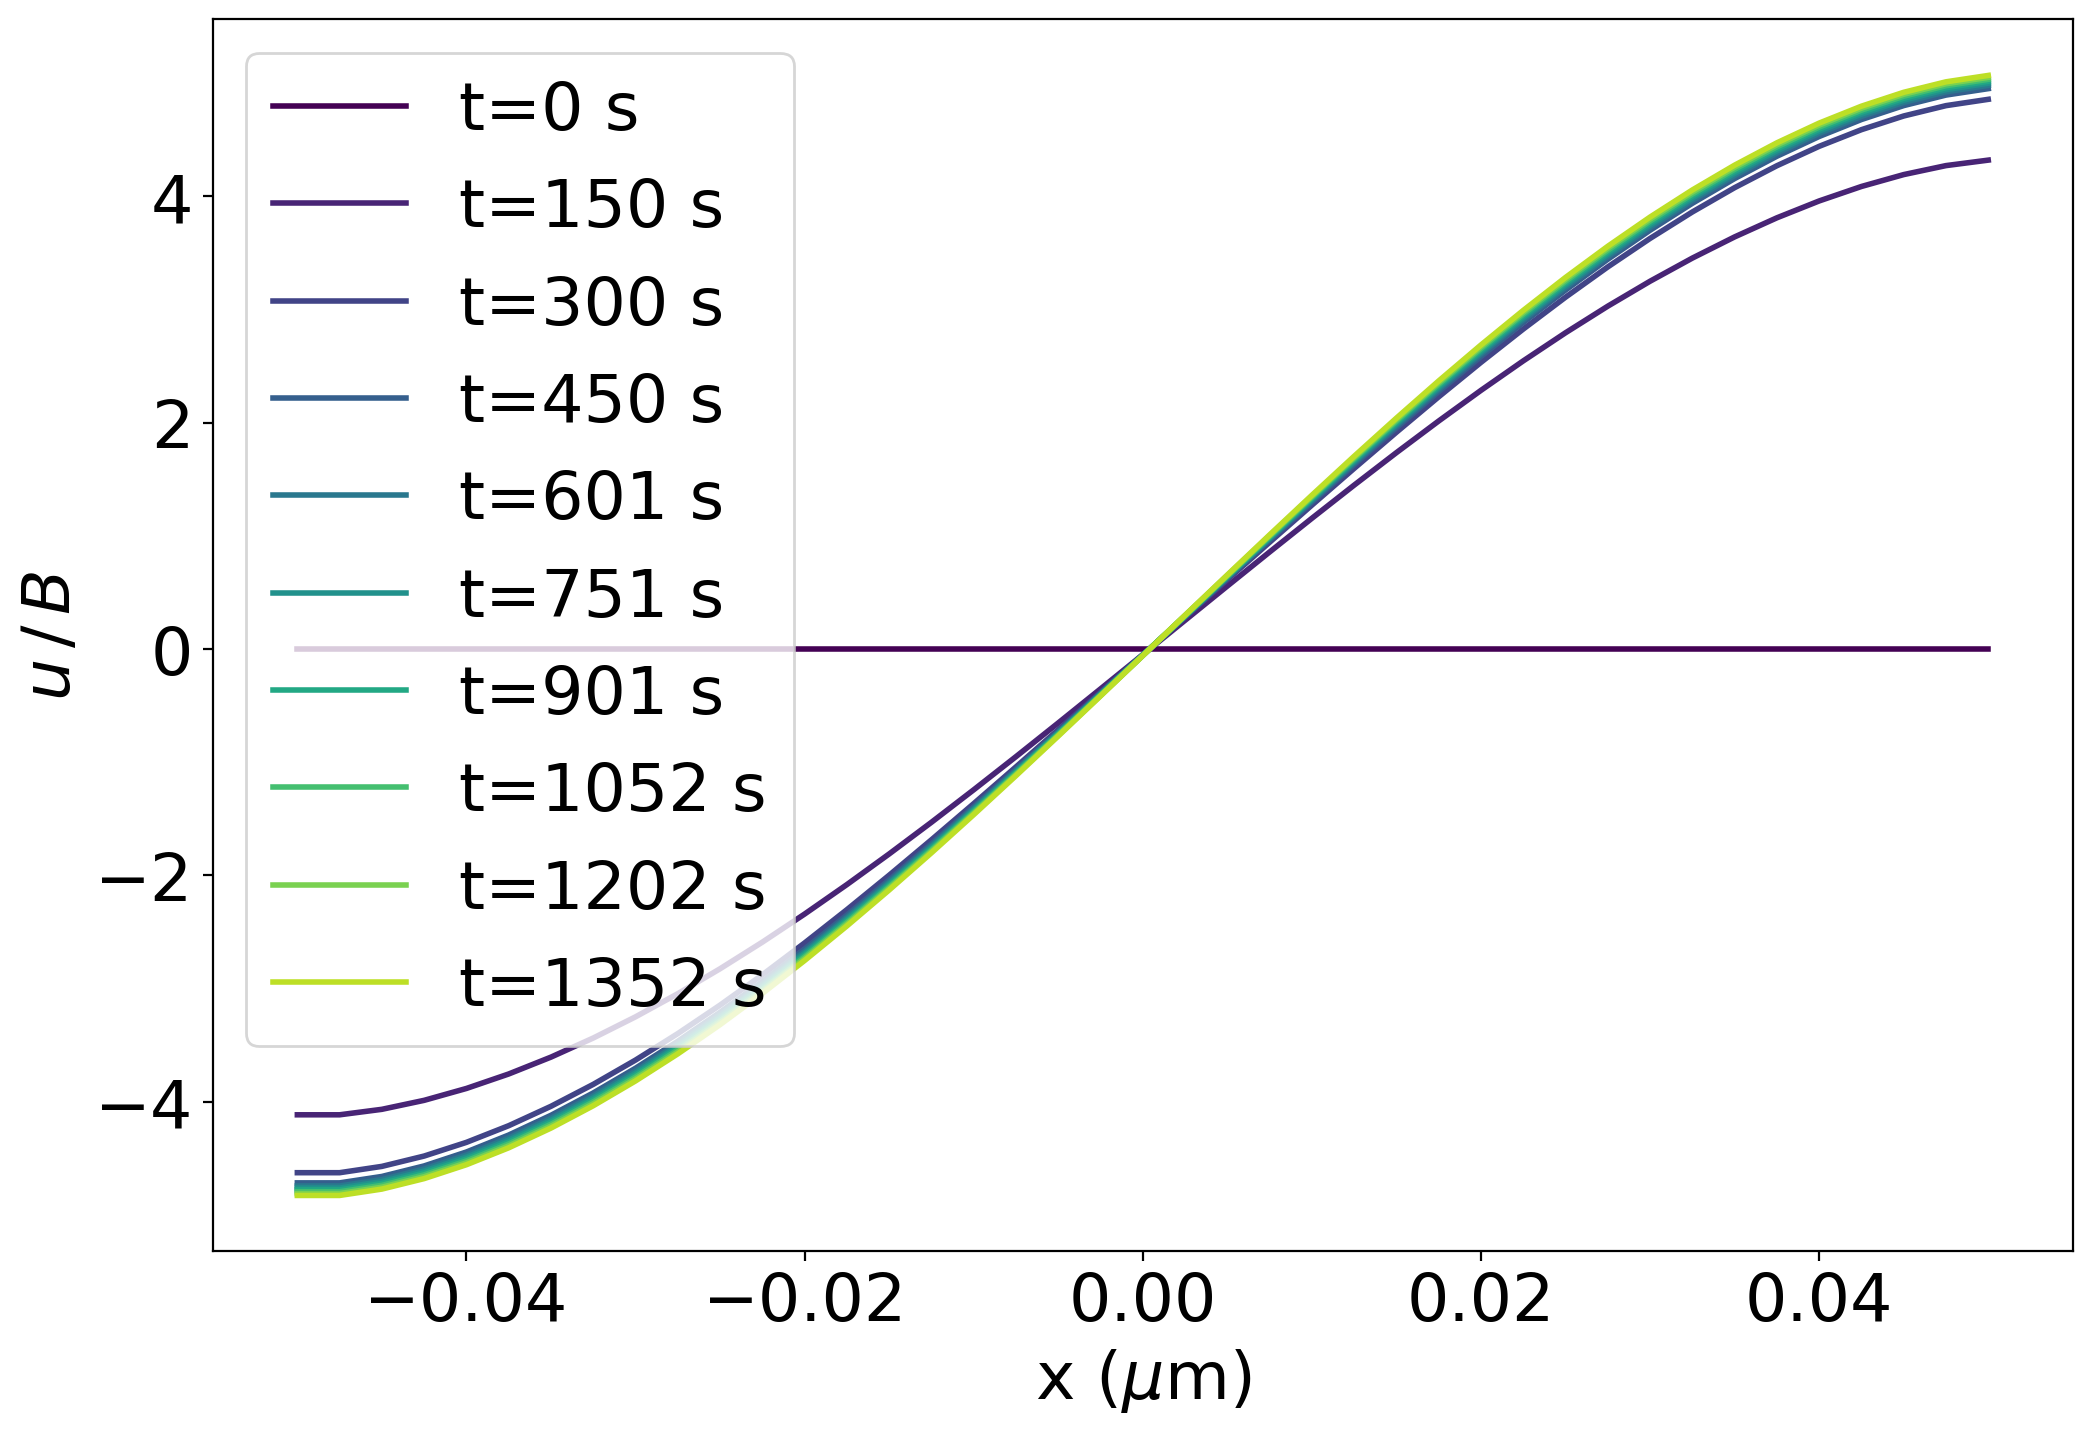

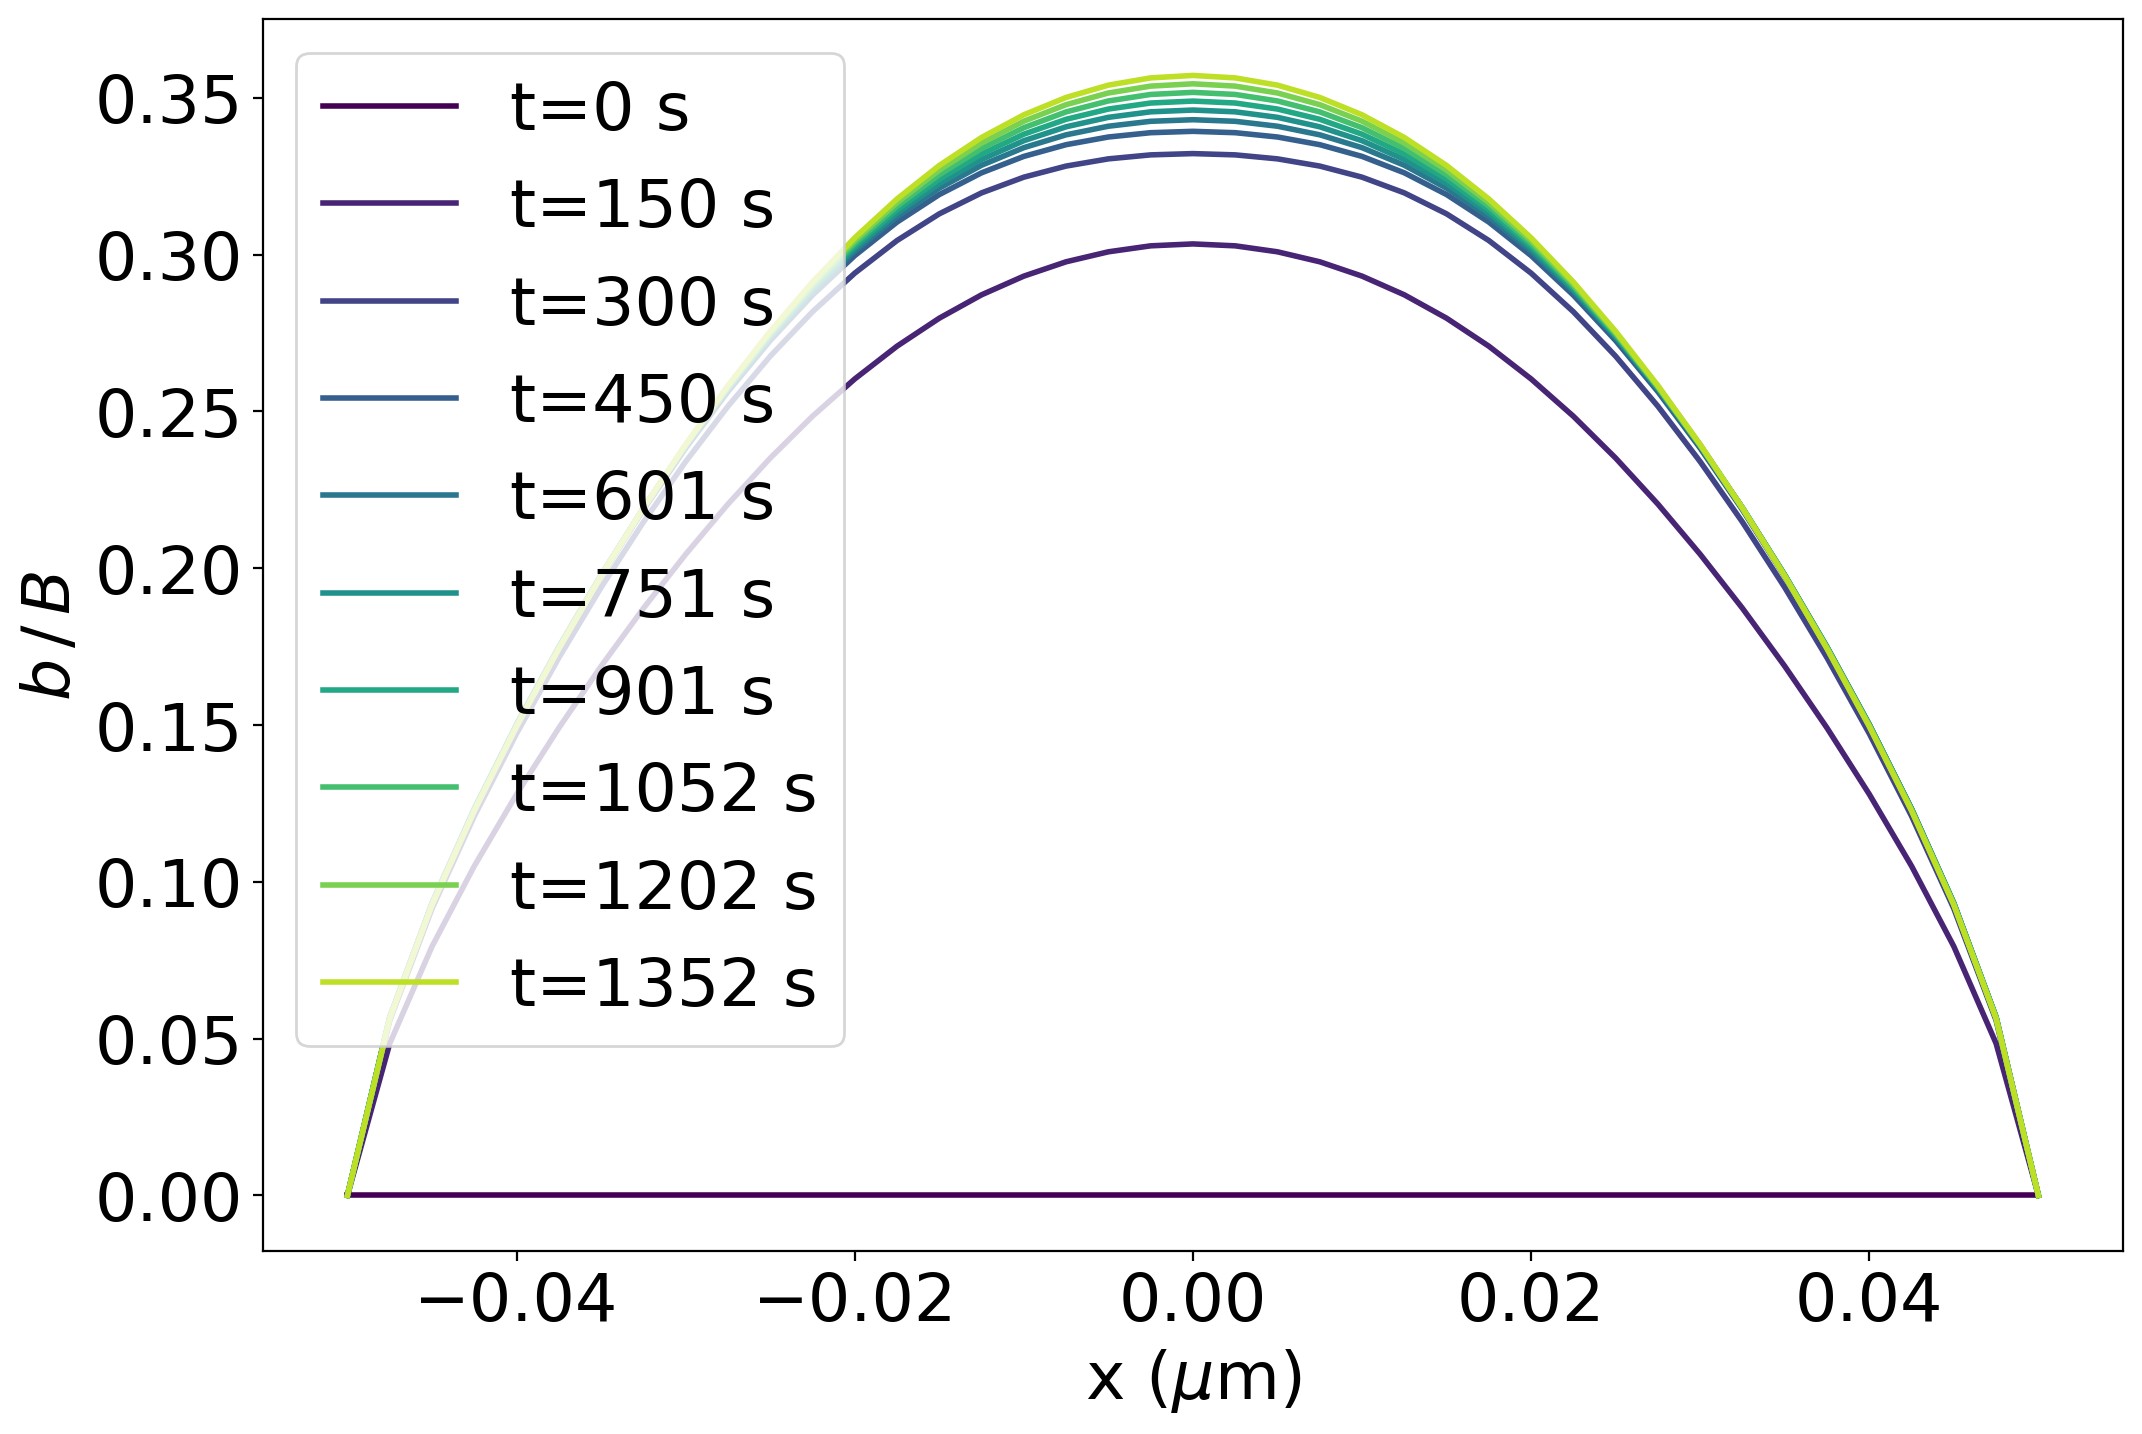

In [4]:
# run simulation chain
for i, ngbn in enumerate(nlist):
    delta = lgb/(ngbn - 1)  # 0.005
    dtmax = 6.25e-7/delta**4  # value 1.e4 for delta=0.005, 50. for PU
    print(f"Simulation with N_gbn={ngbn}, delta={delta}, dtmax={dtmax}")
    gbdd = dd.GB_dislocations(temp=temp, tau0=tau0,
                       Ngbn=ngbn, len_gb_seg=lgb, grain_size=grain_size,
                       tfin=tfin, niter=niter, maxout=maxout,
                       dtmax=dtmax,
                       screenout=True)
    gbdd.run_sim()
    gbdd.save_hdf5(f"pu1_tau{int(tau0)}_T{int(temp)}_N{ngbn}.h5")
    gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
    #gbdd.plot_time_series('plastic_slip')
    gbdd.plot_time_series('plast_slip_rate')
    gbdd.plot_field('displacement')
    gbdd.plot_field('bfield')
    nit[i] = gbdd.nout
    Ngb_list[i] = gbdd.Ngbn
    sim_time[i, 0:gbdd.nout] = gbdd.sim_time
    psr_av[i, 0:gbdd.nout-1] = savgol_filter(gbdd.glob_data['psr_av'][:-1], window_length=25, polyorder=1, deriv=0)
    gplast[i, 0:gbdd.nout] = gbdd.glob_data['plastic_slip']

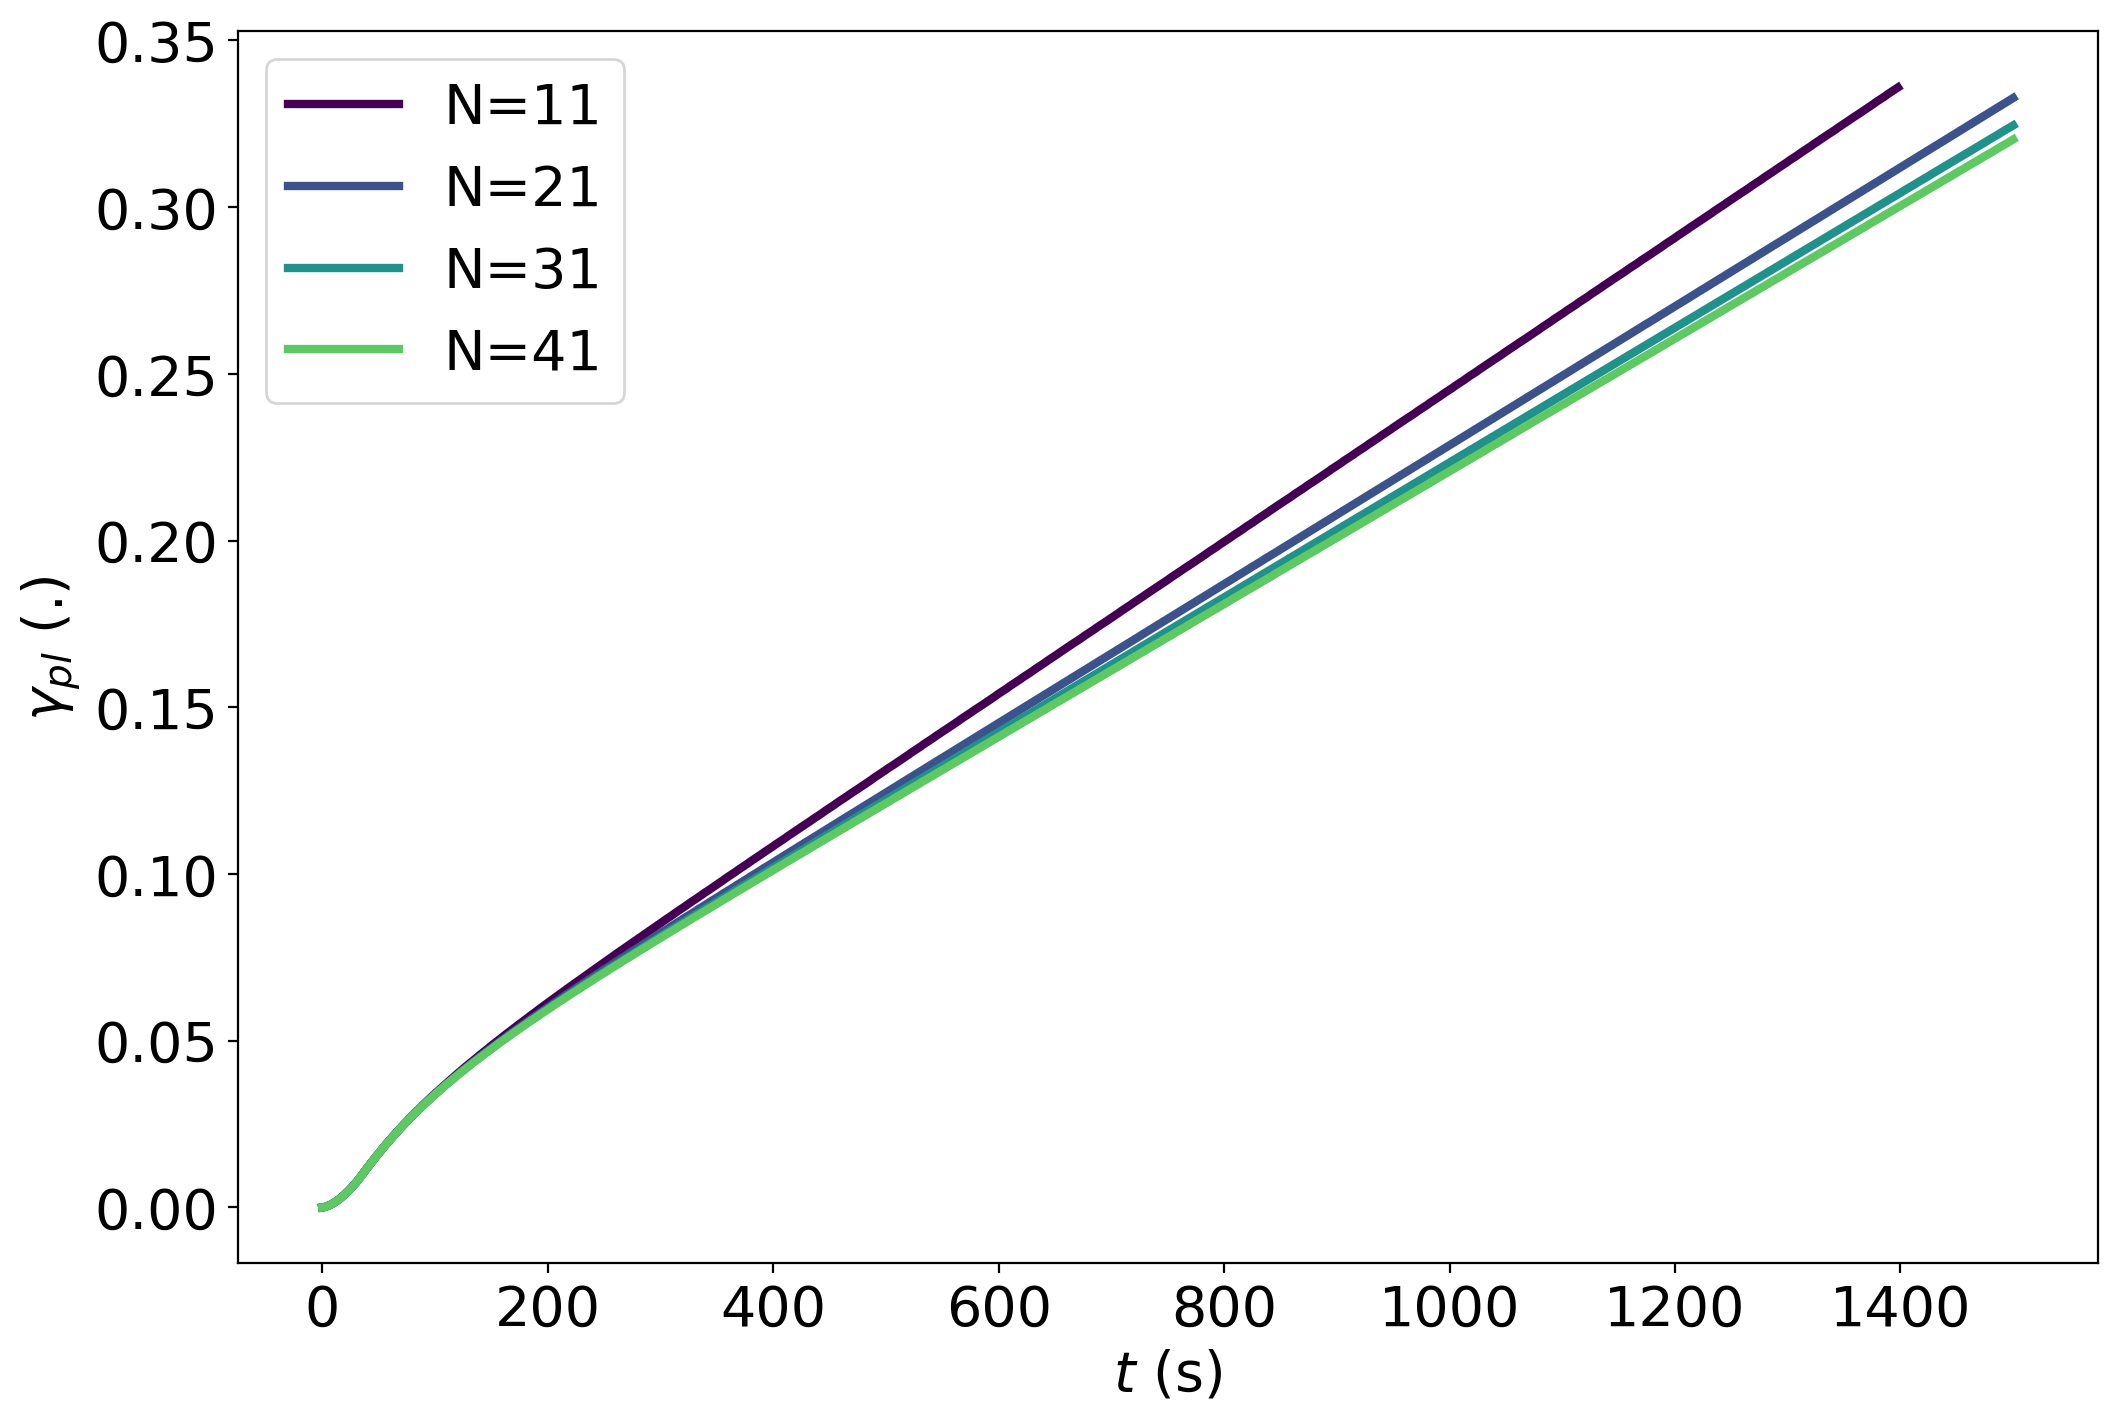

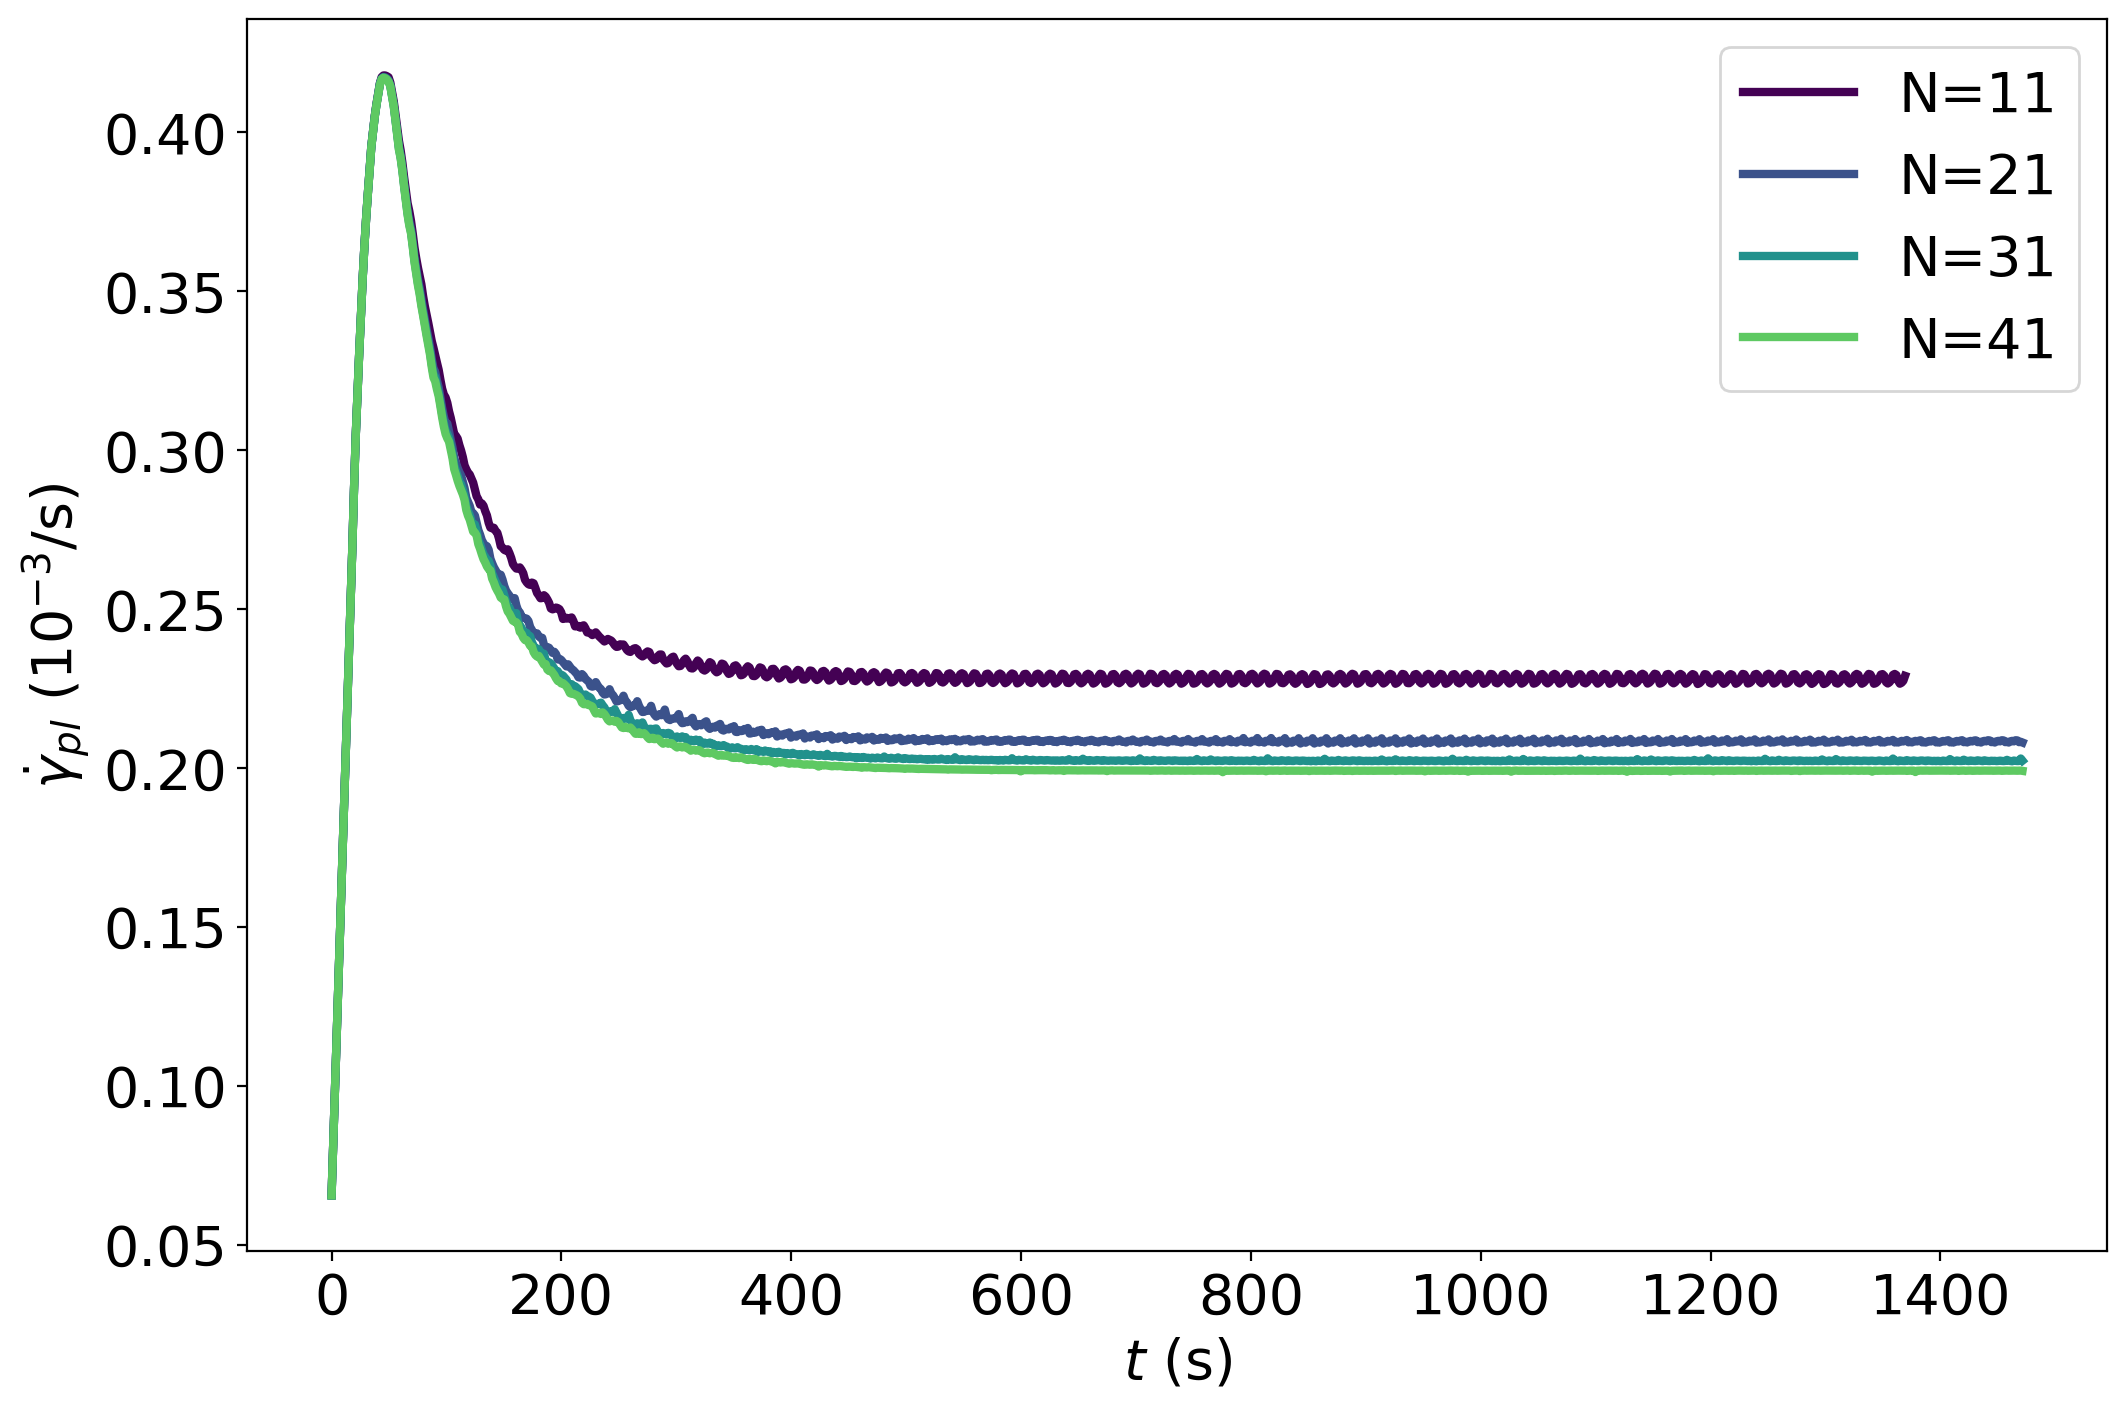

In [5]:
# analysze and plot results
plt.rcParams["font.size"] = 20
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
for i in range(Np):
    plt.plot(sim_time[i, :nit[i]]*1.e-6,
             gplast[i, :nit[i]],
             marker="none",
             linestyle="-",
             linewidth=3,
             color=plt.cm.viridis(i / max(1, Np)),
             label=f"N={Ngb_list[i]}"
             )
plt.legend()
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$\gamma_{pl}$ (.)")
#plt.savefig('pu1_conv_gpl_ngbn.pdf', dpi=300, format='pdf')
plt.show()

fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
for i in range(Np):
    plt.plot(sim_time[i, :nit[i]-20]*1.e-6,
             psr_av[i, :nit[i]-20]*1.e9,
             marker="none",
             linestyle="-",
             linewidth=3,
             color=plt.cm.viridis(i / max(1, Np)),
             label=f"N={Ngb_list[i]}"
             )
plt.legend()
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$\dot\gamma_{pl}$ (10$^{-3}$/s)")
plt.savefig('pu1_conv_gd_ngbn.pdf', dpi=300, format='pdf')
plt.show()